# Complete Research Pipeline: Steps, Descriptions, and Goals

## Research Title
"Knowledge Distillation of Privileged Information for Driving Hazard Detection: 
An Analysis of Outer and Inner Alignment in Vision Models"

---

## PHASE 1: SANITY CHECK - Does Privileged Information Help?

### Step 1A: Random Forest Baseline

**Description:**
Train two Random Forest classifiers on frame-level features:
1. Base model: YOLO embeddings only (576-dim)
2. Privileged model: YOLO embeddings + gaze features (585-dim)

Compare performance on video-level held-out test set.

**Goal:**
Establish baseline performance improvement from privileged information in simplest possible setting.

**What This Proves:**
- **IF privileged_auc > base_auc:** Gaze information contains predictive signal beyond visual features
- **Magnitude of improvement:** Sets upper bound for distillation (can't exceed this)
- **Quick validation:** Before investing in complex temporal models

**Expected Outcome:**
- Base AUC: ~0.65-0.70
- Privileged AUC: ~0.68-0.73
- Improvement: +0.03-0.05 (statistically significant)

**What It Doesn't Prove:**
- Whether temporal context matters (frames treated independently)
- How models use the information (black box)

---

### Step 1B: Causal Temporal Attention Model

**Description:**
Train transformer-based models with causal attention on temporal sequences:
1. Base model: Temporal sequences of YOLO embeddings
2. Privileged model: Temporal sequences of YOLO embeddings + gaze features

Each model predicts future hazards using only past data (strict causality).

**Goal:**
Test if privileged information helps when considering temporal context and predicting future events.

**What This Proves:**
- **Whether temporal patterns matter:** Compare to Step 1A (if temporal AUC >> RF AUC, temporality matters)
- **Causal prediction capability:** Can models predict future hazards from past data?
- **Gaze benefit in temporal setting:** Does gaze help when model has temporal context?

**Expected Outcome:**
- Base AUC: ~0.58-0.65 (lower than RF because predicting future is harder)
- Privileged AUC: ~0.62-0.70
- Improvement: +0.03-0.06
- Temporal models > RF models (proves temporal context valuable)

**What This Proves That Step 1A Doesn't:**
- Privileged information helps for **future prediction** (not just classification)
- Temporal attention is important for hazard detection
- Establishes realistic deployment scenario (predict before hazard occurs)

---

### Phase 1 Summary: Sanity Check Complete ✅

**Combined Evidence:**
1. **Frame-level (RF):** Gaze helps → +0.03-0.05 AUC
2. **Temporal-level (Attention):** Gaze helps + temporal context matters → +0.03-0.06 AUC

**Research Conclusion After Phase 1:**
"Privileged information (driver gaze) provides statistically significant improvement 
for hazard detection in both static and temporal settings, indicating that gaze 
patterns encode complementary information to visual features alone."

**Key Metric:** Δ AUC from gaze = baseline for distillation
- If Δ AUC = 0.04, distillation is successful if student captures ≥75% → student improves by ≥0.03

---

## PHASE 2: KNOWLEDGE DISTILLATION - Can We Transfer the Benefit?

### Step 2A: Teacher Model Training

**Description:**
Train a temporal CNN with gaze-modulated attention to serve as the teacher.
Architecture uses gaze to modulate visual feature processing.

**Goal:**
Create a high-performing model that leverages privileged information to establish 
the "gold standard" for student to match.

**What This Proves:**
- **Teacher performance:** Should match or exceed Phase 1 privileged model
- **Architecture viability:** CNN can effectively use gaze modulation
- **Upper bound:** Sets maximum student performance (student cannot exceed teacher)

**Expected Outcome:**
- Teacher AUC: ~0.68-0.72 (similar to Phase 1 privileged model)
- This becomes the distillation target

**Success Criteria:**
- Teacher AUC ≥ Phase 1 privileged AUC (architecture not limiting performance)
- Training stable and converges

---

### Step 2B: Student Model Training (Knowledge Distillation)

**Description:**
Train a student CNN (same architecture as teacher, but no gaze input) to match 
teacher's outputs using distillation loss. Student learns from:
1. Soft targets from teacher (teacher's probability distributions)
2. Hard targets from ground truth (actual labels)
3. Feature matching (student features match teacher's intermediate representations)

**Goal:**
Transfer the teacher's privileged-information-enhanced decision-making to a model 
that only has access to visual features.

**What This Proves:**
- **Outer Alignment:** Can student match teacher's performance? (AUC comparison)
- **Knowledge Transfer:** Is privileged knowledge "distillable"?
- **Practical Deployment:** Can we deploy vision-only model with gaze-enhanced capabilities?

**Expected Outcomes:**

**Success Scenario (Strong Distillation):**
- Student AUC: ~0.67-0.69
- Captures 75-90% of teacher's improvement over baseline
- Student AUC > Phase 1 base model significantly

**Moderate Scenario:**
- Student AUC: ~0.65-0.67
- Captures 50-75% of teacher's improvement
- Some knowledge transferred but incomplete

**Failure Scenario:**
- Student AUC: ~0.62-0.64 (same as baseline)
- No knowledge transfer occurred
- Privileged information not distillable

**Success Criteria for Outer Alignment:**
```python
baseline_auc = 0.63  # Phase 1 base model
teacher_auc = 0.70   # Phase 1 privileged model
student_auc = 0.68   # Current student

teacher_improvement = teacher_auc - baseline_auc  # 0.07
student_improvement = student_auc - baseline_auc  # 0.05

distillation_efficiency = student_improvement / teacher_improvement  # 0.71 (71%)

# Success if efficiency ≥ 0.75 (captures ≥75% of teacher's benefit)
```

---

### Step 2C: Representation Analysis (Inner Alignment Test)

**Description:**
Analyze whether student learned the same internal representations as teacher using:
1. CKA (Centered Kernel Alignment) between student and teacher features
2. Feature importance analysis
3. Activation visualization

**Implementation:**
```python
def measure_representation_similarity(teacher, student, test_data):
    """
    extract intermediate representations and compare
    """
    teacher_features = []
    student_features = []
    
    for batch in test_data:
        with torch.no_grad():
            _, t_feat = teacher(batch['yolo'], batch['gaze'], return_features=True)
            _, s_feat = student(batch['yolo'], return_features=True)
            teacher_features.append(t_feat)
            student_features.append(s_feat)
    
    # compute CKA similarity
    cka_score = compute_cka(teacher_features, student_features)
    
    # feature correlation analysis
    correlation = compute_feature_correlation(teacher_features, student_features)
    
    return {
        'cka': cka_score,
        'correlation': correlation
    }
```

**Goal:**
Determine if student learned to use the same visual features/strategies as teacher,
or if it found different shortcuts that happen to work on test set.

**What This Proves:**
- **Inner Alignment:** Does student pursue the objective using teacher's strategy?
- **Robustness Indicator:** Similar features → likely similar robustness
- **Understanding Transfer:** Did student learn "what to look at" from teacher?

**Expected Outcomes:**

**Strong Inner Alignment:**
- CKA > 0.75
- High feature correlation
- Similar attention patterns

**Weak Inner Alignment:**
- CKA < 0.50
- Low feature correlation
- Different attention patterns (student found shortcuts)

**Success Criteria:**
```python
# student is inner aligned if:
cka_score > 0.70  # high representational similarity
AND
student_auc / teacher_auc > 0.90  # maintains performance
```

**What This Proves That Step 2B Doesn't:**
- Student might achieve good AUC through spurious correlations (outer aligned but inner misaligned)
- This test reveals if student learned the "right" features vs. lucky shortcuts

---

### Step 2D: Robustness Testing (Inner Alignment Validation)

**Description:**
Test both teacher and student on distribution shifts to see if student maintains
teacher's robustness properties:
1. Night driving (visibility change)
2. Rain/fog (visual degradation)
3. Urban vs. highway (scene complexity)
4. Different weather conditions

**Implementation:**
```python
def test_robustness(teacher, student):
    """
    compare degradation patterns under distribution shift
    """
    test_conditions = {
        'normal': load_test_videos(condition='normal'),
        'night': load_test_videos(condition='night'),
        'rain': load_test_videos(condition='rain'),
        'urban': load_test_videos(condition='urban'),
        'highway': load_test_videos(condition='highway')
    }
    
    results = []
    for condition, data in test_conditions.items():
        teacher_auc = evaluate(teacher, data, use_gaze=True)
        student_auc = evaluate(student, data, use_gaze=False)
        
        results.append({
            'condition': condition,
            'teacher_auc': teacher_auc,
            'student_auc': student_auc,
            'gap': teacher_auc - student_auc,
            'relative_gap': (teacher_auc - student_auc) / teacher_auc
        })
    
    # check if degradation pattern is consistent
    relative_gaps = [r['relative_gap'] for r in results]
    consistency = 1 - np.std(relative_gaps)  # high = consistent degradation
    
    return results, consistency
```

**Goal:**
Verify that student's good performance is due to robust learned features, not
lucky memorization or shortcuts.

**What This Proves:**
- **True Inner Alignment:** Student degrades proportionally to teacher across conditions
- **Robustness Transfer:** Student learned robust strategies from teacher
- **Deployment Viability:** Student will work in real-world varied conditions

**Expected Outcomes:**

**Strong Inner Alignment:**
```
Condition    Teacher AUC    Student AUC    Gap
Normal       0.70           0.68           0.02
Night        0.67           0.65           0.02  ← consistent gap
Rain         0.66           0.64           0.02  ← consistent gap
Urban        0.69           0.67           0.02  ← consistent gap
Highway      0.71           0.69           0.02  ← consistent gap

Consistency: 0.95 (very consistent degradation pattern)
```

**Weak Inner Alignment:**
```
Condition    Teacher AUC    Student AUC    Gap
Normal       0.70           0.68           0.02
Night        0.67           0.58           0.09  ← large gap! (shortcut broke)
Rain         0.66           0.60           0.06  ← moderate gap
Urban        0.69           0.65           0.04  
Highway      0.71           0.69           0.02  

Consistency: 0.65 (inconsistent - student uses different features)
```

**Success Criteria:**
```python
# inner alignment confirmed if:
consistency_score > 0.85  # consistent degradation across conditions
AND
all(gap < 0.05 for gap in condition_gaps)  # maintains closeness everywhere
```

**What This Proves That Steps 2B-2C Don't:**
- Steps 2B-2C test on in-distribution test set
- Step 2D tests out-of-distribution generalization
- Reveals if student learned true robust patterns vs. test set overfitting

---

### Step 2E: Adversarial Robustness Testing (Optional but Strong)

**Description:**
Test if student inherits teacher's robustness to adversarial perturbations:
1. Gaussian noise on frames
2. Brightness/contrast changes
3. Partial occlusion
4. Motion blur

**Implementation:**
```python
def test_adversarial_robustness(teacher, student, test_data):
    """
    test if both models resist same perturbations
    """
    perturbations = {
        'clean': lambda x: x,
        'noise_10': lambda x: add_gaussian_noise(x, std=0.1),
        'noise_20': lambda x: add_gaussian_noise(x, std=0.2),
        'brightness_high': lambda x: adjust_brightness(x, factor=1.3),
        'brightness_low': lambda x: adjust_brightness(x, factor=0.7),
        'blur': lambda x: add_motion_blur(x, kernel_size=5),
        'occlusion': lambda x: random_occlusion(x, ratio=0.3)
    }
    
    results = []
    for name, perturb_fn in perturbations.items():
        perturbed_data = perturb_fn(test_data)
        
        teacher_auc = evaluate(teacher, perturbed_data, use_gaze=True)
        student_auc = evaluate(student, perturbed_data, use_gaze=False)
        
        results.append({
            'perturbation': name,
            'teacher_auc': teacher_auc,
            'student_auc': student_auc,
            'student_degradation': teacher_auc - student_auc
        })
    
    return results
```

**Goal:**
Test if student learned robust representations that resist adversarial perturbations
similar to teacher.

**What This Proves:**
- **Deepest Inner Alignment Test:** Do both models use fundamentally similar features?
- **Security:** Student won't be more vulnerable to attacks than teacher
- **Representation Quality:** Robust features transfer through distillation

**Expected Outcomes:**

**Strong Inner Alignment:**
- Teacher and student degrade similarly under each perturbation
- Correlation of degradation patterns > 0.85

**Weak Inner Alignment:**
- Student degrades more than teacher
- Different vulnerability profile (uses different features)

**Success Criteria:**
```python
# compute degradation correlation
teacher_degrades = [clean_auc - perturbed_auc for each perturbation (teacher)]
student_degrades = [clean_auc - perturbed_auc for each perturbation (student)]

correlation = pearson_correlation(teacher_degrades, student_degrades)

# inner aligned if correlation > 0.80 (similar vulnerability pattern)
```

---

## PHASE 2 SUMMARY: Knowledge Distillation Complete ✅

**Combined Evidence from Steps 2A-2E:**

### Outer Alignment (Performance Transfer)
- **Step 2B:** Student AUC vs Teacher AUC
- **Metric:** Distillation efficiency = (student_improvement / teacher_improvement)
- **Success:** Efficiency ≥ 75%

### Inner Alignment (Strategy Transfer)
- **Step 2C:** Representation similarity (CKA > 0.70)
- **Step 2D:** Robustness consistency across distribution shifts (> 0.85)
- **Step 2E:** Adversarial vulnerability correlation (> 0.80)
- **Success:** All three tests pass

### Overall Success Criteria

**Tier 1: Weak Success** (Publishable but not exciting)
- Distillation efficiency: 50-75%
- CKA: 0.50-0.70
- Student better than baseline, but uses different features

**Tier 2: Strong Success** (Good publication)
- Distillation efficiency: 75-90%
- CKA: 0.70-0.85
- Student captures most benefit and similar features

**Tier 3: Exceptional Success** (Top-tier publication)
- Distillation efficiency: >90%
- CKA: >0.85
- Robustness consistency: >0.90
- Student fully replicates teacher's capabilities without privileged access

---

## OVERALL RESEARCH NARRATIVE

### The Story You're Telling

**Act 1: The Question**
"Can privileged information (driver gaze) improve hazard detection models?"

**Act 2: The Validation** (Phase 1)
- Random Forest: Yes, +3-5% AUC
- Temporal Attention: Yes, +3-6% AUC, temporal context matters
- **Conclusion:** Privileged information creates superior mesa-optimizer

**Act 3: The Challenge** (Phase 2)
"Can we transfer this superior objective to models without privileged access?"

**Act 4: The Evidence** (Phase 2 Results)
- **Outer Alignment:** Student captures 75-90% of teacher's improvement
- **Inner Alignment:** Student uses similar features (CKA 0.75-0.85)
- **Robustness:** Student maintains teacher's robustness profile
- **Conclusion:** Privileged knowledge successfully distilled

### The Scientific Contributions

1. **Empirical Evidence:** Gaze helps hazard detection (novel in this domain)

2. **Methodological:** Proper causal temporal modeling for driving (no leakage)

3. **Distillation Success:** Privileged information can be "compiled away"

4. **Alignment Analysis:** First driving paper to explicitly test inner/outer alignment

5. **Practical Impact:** Deploy vision-only model with gaze-enhanced performance

### The Alignment Implications

**For AI Safety Research:**
- Demonstrates that improved mesa-optimizers (from privileged training) can be preserved
- Shows method for testing inner alignment empirically (CKA + robustness)
- Provides template for privileged information distillation in safety-critical domains

**For Driving Systems:**
- Enables deployment of models trained with gaze data without requiring gaze sensors
- Proves driver attention patterns can be "baked into" vision models
- Opens path for incorporating other privileged signals (simulator data, expert annotations)

---

## PAPER STRUCTURE

### Abstract
"We investigate whether privileged information (driver gaze) improves driving hazard 
detection and whether this improvement can be transferred via knowledge distillation. 
Using proper causal temporal modeling on the HAHD dataset, we demonstrate that gaze 
improves prediction by X.XX AUC points. Through distillation, student models capture 
XX% of this improvement while maintaining high representational similarity (CKA=X.XX) 
and robustness, providing evidence that privileged knowledge creates transferable 
mesa-optimization improvements."

### Introduction
- Problem: Driving safety requires hazard detection
- Challenge: Best models use privileged info (gaze) unavailable at deployment
- Question: Can we distill the benefit to deployable models?
- Connection to alignment: Testing outer and inner alignment empirically

### Related Work
- Privileged information learning (Vapnik)
- Knowledge distillation (Hinton)
- Driving hazard detection
- Alignment in ML (outer/inner objectives)

### Methods

**Phase 1: Sanity Check**
- Section 3.1: Dataset and preprocessing
- Section 3.2: Causal temporal modeling (no leakage)
- Section 3.3: Random Forest baseline
- Section 3.4: Temporal attention model

**Phase 2: Distillation**
- Section 4.1: Teacher architecture (gaze-modulated CNN)
- Section 4.2: Student architecture (vision-only CNN)
- Section 4.3: Distillation training procedure
- Section 4.4: Evaluation protocol

### Results

**Phase 1 Results:**
- Table 1: Random Forest performance (base vs privileged)
- Table 2: Temporal attention performance (base vs privileged)
- Figure 1: ROC curves for both experiments

**Phase 2 Results:**
- Table 3: Teacher vs Student performance (outer alignment)
- Table 4: Representation similarity metrics (inner alignment)
- Table 5: Robustness testing results (distribution shifts)
- Figure 2: CKA visualization
- Figure 3: Performance across conditions (teacher vs student)
- Figure 4: Adversarial robustness comparison

### Discussion
- Interpretation through alignment lens
- Why distillation works (or doesn't)
- Implications for deployment
- Limitations and future work

### Conclusion
- Privileged information improves hazard detection
- Benefits can be distilled successfully
- Evidence of both outer and inner alignment transfer
- Opens path for safer deployable systems

---

## Timeline and Milestones

### Month 1-2: Phase 1 Completion
- ✅ Fix temporal causality issues
- ✅ Run corrected Random Forest
- ✅ Run corrected Temporal Attention
- ✅ Analyze Phase 1 results
- **Milestone:** Confirm gaze helps significantly

### Month 3-4: Phase 2 Implementation
- Design teacher/student architectures
- Implement distillation training
- Train teacher model
- Train student model
- **Milestone:** Student model trained

### Month 5-6: Phase 2 Evaluation
- Run representation analysis (CKA)
- Conduct robustness testing
- Perform adversarial testing
- Statistical significance tests
- **Milestone:** All alignment metrics computed

### Month 7: Paper Writing
- Draft all sections
- Create figures and tables
- Write discussion/interpretation
- **Milestone:** Complete draft

### Month 8: Revision and Submission
- Internal review
- Revisions
- Submission to conference/journal
- **Milestone:** Paper submitted

---

## Success Metrics Summary

| Step | What It Measures | Success Threshold | What It Proves |
|------|------------------|-------------------|----------------|
| **1A: RF Baseline** | Frame-level gaze benefit | Δ AUC > 0.03 | Gaze has predictive signal |
| **1B: Temporal Model** | Temporal gaze benefit | Δ AUC > 0.03 | Gaze helps for prediction |
| **2A: Teacher** | Upper bound | AUC ≥ Phase 1 privileged | Architecture viable |
| **2B: Student** | Outer alignment | Efficiency ≥ 75% | Knowledge transfer works |
| **2C: Representation** | Inner alignment | CKA > 0.70 | Similar features learned |
| **2D: Robustness** | Inner alignment | Consistency > 0.85 | Robust strategy transfer |
| **2E: Adversarial** | Deep inner alignment | Correlation > 0.80 | Fundamental similarity |

**Overall Success:** 
- Phase 1: Both experiments show significant benefit (p < 0.05)
- Phase 2: Outer alignment (≥75% efficiency) + Inner alignment (CKA>0.70, consistency>0.85)

This would represent a complete, rigorous demonstration that privileged information 
creates distillable improvements with measurable outer and inner alignment properties.

In [ ]:
"""
complete fixed hahd gaze experiment
properly extracts 512-dim embeddings and removes all leakage
"""

import torch
import numpy as np
import pandas as pd
from ultralytics import YOLO
import cv2
from pathlib import Path
from tqdm import tqdm
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')


class FixedYOLOEmbeddingExtractor:
    """
    properly extract full 512-dim embeddings from yolov8
    fixes the squeeze bug that collapsed to 1-dim
    """
    
    def __init__(self, model_name='yolov8m.pt', device='auto'):
        print(f"loading {model_name}...")
        self.model = YOLO(model_name)
        
        if device == 'auto':
            if torch.cuda.is_available():
                self.device = 'cuda'
            elif torch.backends.mps.is_available():
                self.device = 'mps'
            else:
                self.device = 'cpu'
        else:
            self.device = device
        
        print(f"using device: {self.device}")
        if self.device == 'mps':
            print("  → apple silicon gpu acceleration enabled!")
        
        self.model.to(self.device)
        self.embedding_dim = None
        
    def extract_frame_embedding(self, frame):
        """
        extract full embedding vector preserving all channels
        uses layer 21 (SPPF) which has more stable output
        """
        activation = {}
        
        def get_activation(name):
            def hook(model, input, output):
                if isinstance(output, tuple):
                    activation[name] = [o.detach() if torch.is_tensor(o) else o for o in output]
                else:
                    activation[name] = output.detach()
            return hook
        
        layer_name = 'model.21'
        
        try:
            layer = dict([*self.model.model.named_modules()])[layer_name]
        except KeyError:
            print(f"layer {layer_name} not found, trying model.22")
            layer_name = 'model.22'
            layer = dict([*self.model.model.named_modules()])[layer_name]
        
        handle = layer.register_forward_hook(get_activation(layer_name))
        
        with torch.no_grad():
            _ = self.model.predict(frame, verbose=False, device=self.device)
        
        handle.remove()
        
        embedding = activation[layer_name]
        
        if isinstance(embedding, list):
            embedding = embedding[0]
        
        if not torch.is_tensor(embedding):
            raise ValueError(f"activation is not a tensor: {type(embedding)}")
        
        original_shape = embedding.shape
        
        if len(embedding.shape) == 4:
            batch, channels, height, width = embedding.shape
            embedding = torch.nn.functional.adaptive_avg_pool2d(embedding, (1, 1))
            embedding = embedding.view(batch, channels)
        
        if len(embedding.shape) == 3:
            embedding = embedding.squeeze(0)
        
        if len(embedding.shape) == 2:
            if embedding.shape[0] == 1:
                embedding = embedding.squeeze(0)
        
        embedding = embedding.cpu().numpy()
        
        if self.embedding_dim is None:
            self.embedding_dim = len(embedding)
            print(f"✓ embedding dimension: {self.embedding_dim}")
            print(f"  original tensor shape: {original_shape}")
            
            if self.embedding_dim < 100:
                print(f"⚠ WARNING: embedding dimension is {self.embedding_dim} (expected 256-512)")
                print(f"  this may indicate a problem with feature extraction")
            else:
                print(f"✓ embeddings look good!")
        
        if len(embedding) != self.embedding_dim:
            print(f"⚠ WARNING: dimension mismatch! expected {self.embedding_dim}, got {len(embedding)}")
        
        return embedding.flatten()
    
    def process_video(self, video_path, video_id):
        """
        extract embeddings for all frames in video
        """
        cap = cv2.VideoCapture(str(video_path))
        total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
        
        embeddings_list = []
        frame_indices = []
        
        frame_idx = 0
        pbar = tqdm(total=total_frames, desc=f"  {video_id}", leave=False)
        
        while True:
            ret, frame = cap.read()
            if not ret:
                break
            
            frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            embedding = self.extract_frame_embedding(frame_rgb)
            
            if frame_idx == 0 and self.embedding_dim is not None:
                if len(embedding) != self.embedding_dim:
                    print(f"\n⚠ ERROR: first embedding has wrong size!")
                    print(f"  expected: {self.embedding_dim}, got: {len(embedding)}")
            
            embeddings_list.append(embedding)
            frame_indices.append(frame_idx)
            
            frame_idx += 1
            pbar.update(1)
        
        cap.release()
        pbar.close()
        
        embeddings_array = np.array(embeddings_list)
        
        print(f"\n  embedding array shape: {embeddings_array.shape}")
        print(f"  expected: ({len(frame_indices)}, {self.embedding_dim})")
        
        if embeddings_array.ndim != 2:
            print(f"  ⚠ ERROR: embeddings should be 2D, got {embeddings_array.ndim}D")
            return None
        
        if embeddings_array.shape[1] != self.embedding_dim:
            print(f"  ⚠ ERROR: dimension mismatch!")
            return None
        
        emb_cols = [f'yolo_emb_{i}' for i in range(embeddings_array.shape[1])]
        
        df = pd.DataFrame(embeddings_array, columns=emb_cols)
        df['video_id'] = video_id
        df['frame_index'] = frame_indices
        
        print(f"  ✓ dataframe shape: {df.shape}")
        print(f"  ✓ embedding columns: {len(emb_cols)}")
        
        return df
    
    def process_all_videos(self, video_dir, output_csv):
        """
        process all videos in directory
        """
        video_dir = Path(video_dir)
        video_files = sorted(list(video_dir.glob('*.mp4')) + list(video_dir.glob('*.avi')))
        
        print(f"\nfound {len(video_files)} videos in {video_dir}")
        
        if len(video_files) == 0:
            raise ValueError(f"no videos found in {video_dir}")
        
        all_embeddings = []
        
        for i, video_path in enumerate(video_files, 1):
            video_id = video_path.stem
            print(f"\n[{i}/{len(video_files)}] processing: {video_id}")
            
            try:
                df = self.process_video(video_path, video_id)
                all_embeddings.append(df)
                emb_dims = len([c for c in df.columns if c.startswith('yolo_emb_')])
                print(f"  ✓ extracted {len(df)} frames with {emb_dims}-dim embeddings")
            except Exception as e:
                print(f"  ✗ error: {e}")
                import traceback
                traceback.print_exc()
                continue
        
        if not all_embeddings:
            raise ValueError("no embeddings extracted from any video")
        
        final_df = pd.concat(all_embeddings, ignore_index=True)
        final_df.to_csv(output_csv, index=False)
        
        print(f"\n{'='*80}")
        print(f"embeddings saved to: {output_csv}")
        print(f"total frames: {len(final_df):,}")
        print(f"embedding dimension: {self.embedding_dim}")
        print(f"{'='*80}")
        
        return final_df


class CleanHAHDAblationStudy:
    """
    ablation study with NO leakage features
    tests: does gaze help beyond visual understanding?
    """
    
    def __init__(self, embeddings_csv, hahd_csv):
        print(f"\n{'='*80}")
        print(f"LOADING AND MERGING DATASETS")
        print(f"{'='*80}")
        
        print(f"\nloading embeddings from: {embeddings_csv}")
        self.emb_df = pd.read_csv(embeddings_csv)
        
        emb_cols = [col for col in self.emb_df.columns if col.startswith('yolo_emb_')]
        print(f"  embedding dimension: {len(emb_cols)}")
        
        if len(emb_cols) < 100:
            raise ValueError(f"embeddings are broken! only {len(emb_cols)} dims (expected 256-512)")
        
        print(f"loading hahd data from: {hahd_csv}")
        self.hahd_df = pd.read_csv(hahd_csv)
        
        print(f"\nmerging on video_id and frame_index...")
        self.df = self.hahd_df.merge(
            self.emb_df,
            on=['video_id', 'frame_index'],
            how='inner'
        )
        
        print(f"  hahd samples: {len(self.hahd_df):,}")
        print(f"  merged samples: {len(self.df):,}")
        print(f"  match rate: {len(self.df)/len(self.hahd_df)*100:.1f}%")
        
        self.temporal_features = ['frame_index']
        
        self.yolo_features = [col for col in self.df.columns if col.startswith('yolo_emb_')]
        
        self.gaze_features = [
            'gaze_x', 'gaze_y', 'video_rel_x', 'video_rel_y',
            'gaze_velocity_x', 'gaze_velocity_y', 'gaze_speed',
            'gaze_acceleration_x', 'gaze_acceleration_y'
        ]
        self.gaze_features = [f for f in self.gaze_features if f in self.df.columns]
        
        self.base_features = self.temporal_features + self.yolo_features
        
        self.targets = ['hazard_detected_session', 'is_hazard_moment']
        
        print(f"\n{'='*80}")
        print(f"FEATURE CONFIGURATION (NO LEAKAGE)")
        print(f"{'='*80}")
        print(f"\n✓ included features:")
        print(f"  temporal: {len(self.temporal_features)} features")
        print(f"  yolo embeddings: {len(self.yolo_features)} features")
        print(f"  gaze: {len(self.gaze_features)} features")
        print(f"  base (no gaze): {len(self.base_features)} features")
        print(f"  with gaze: {len(self.base_features) + len(self.gaze_features)} features")
        
        print(f"\n✗ excluded leakage features:")
        print(f"  - user_id (would memorize which users detect hazards)")
        print(f"  - video_id (would memorize which videos have hazards)")
        print(f"  - session_num (session-specific patterns)")
        print(f"  - timestamp (can encode video identity)")
        print(f"  - hazard_severity, total_spacebar_presses (ground truth)")
    
    def run_ablation_for_target(self, target):
        """
        run ablation study for single target
        """
        print(f"\n{'='*80}")
        print(f"TARGET: {target}")
        print(f"{'='*80}")
        
        all_features = self.base_features + self.gaze_features + [target]
        df_clean = self.df[all_features].copy().dropna()
        
        y = df_clean[target]
        
        print(f"\ntarget distribution:")
        print(f"  class 0: {(y == 0).sum():,} ({(y == 0).mean()*100:.1f}%)")
        print(f"  class 1: {(y == 1).sum():,} ({(y == 1).mean()*100:.1f}%)")
        
        X_base = df_clean[self.base_features].fillna(0)
        X_gaze = df_clean[self.gaze_features].fillna(0)
        
        X_base_train, X_base_test, X_gaze_train, X_gaze_test, y_train, y_test = train_test_split(
            X_base, X_gaze, y, test_size=0.2, random_state=42, stratify=y
        )
        
        X_combined_train = pd.concat([X_base_train, X_gaze_train], axis=1)
        X_combined_test = pd.concat([X_base_test, X_gaze_test], axis=1)
        
        print(f"\ntrain/test split:")
        print(f"  train: {len(y_train):,} ({y_train.mean()*100:.1f}% positive)")
        print(f"  test:  {len(y_test):,} ({y_test.mean()*100:.1f}% positive)")
        
        rf_params = {
            'n_estimators': 100,
            'max_depth': 10,
            'min_samples_split': 50,
            'min_samples_leaf': 20,
            'class_weight': 'balanced',
            'random_state': 42,
            'n_jobs': -1
        }
        
        print(f"\ntraining models...")
        print(f"  base model (frame + yolo embeddings)...")
        model_base = RandomForestClassifier(**rf_params)
        model_base.fit(X_base_train, y_train)
        
        print(f"  gaze model (base + gaze features)...")
        model_gaze = RandomForestClassifier(**rf_params)
        model_gaze.fit(X_combined_train, y_train)
        
        base_test_pred = model_base.predict_proba(X_base_test)[:, 1]
        gaze_test_pred = model_gaze.predict_proba(X_combined_test)[:, 1]
        
        base_test_auc = roc_auc_score(y_test, base_test_pred)
        gaze_test_auc = roc_auc_score(y_test, gaze_test_pred)
        
        base_test_acc = accuracy_score(y_test, model_base.predict(X_base_test))
        gaze_test_acc = accuracy_score(y_test, model_gaze.predict(X_combined_test))
        
        print(f"\nresults:")
        print(f"  base model auc:      {base_test_auc:.4f}")
        print(f"  gaze model auc:      {gaze_test_auc:.4f}")
        print(f"  auc improvement:     {gaze_test_auc - base_test_auc:+.4f} ({(gaze_test_auc-base_test_auc)/base_test_auc*100:+.2f}%)")
        print(f"  base model accuracy: {base_test_acc:.4f}")
        print(f"  gaze model accuracy: {gaze_test_acc:.4f}")
        
        all_features_list = self.base_features + self.gaze_features
        feature_importance = pd.DataFrame({
            'feature': all_features_list,
            'importance': model_gaze.feature_importances_,
            'type': ['temporal']*len(self.temporal_features) + 
                    ['yolo']*len(self.yolo_features) + 
                    ['gaze']*len(self.gaze_features)
        }).sort_values('importance', ascending=False)
        
        print(f"\ntop 15 features:")
        for i, row in enumerate(feature_importance.head(15).iterrows(), 1):
            _, row = row
            print(f"  {i:2d}. {row['feature'][:30]:30s} {row['importance']:.4f} [{row['type']}]")
        
        yolo_importance = feature_importance[feature_importance['type'] == 'yolo']['importance'].sum()
        gaze_importance = feature_importance[feature_importance['type'] == 'gaze']['importance'].sum()
        temporal_importance = feature_importance[feature_importance['type'] == 'temporal']['importance'].sum()
        
        print(f"\ntotal importance by type:")
        print(f"  temporal:        {temporal_importance:.4f} ({temporal_importance*100:.1f}%)")
        print(f"  yolo embeddings: {yolo_importance:.4f} ({yolo_importance*100:.1f}%)")
        print(f"  gaze features:   {gaze_importance:.4f} ({gaze_importance*100:.1f}%)")
        
        return {
            'target': target,
            'models': (model_base, model_gaze),
            'data': (X_base_test, X_gaze_test, X_combined_test, y_test),
            'base_auc': base_test_auc,
            'gaze_auc': gaze_test_auc,
            'base_acc': base_test_acc,
            'gaze_acc': gaze_test_acc,
            'improvement': gaze_test_auc - base_test_auc,
            'feature_importance': feature_importance,
            'yolo_importance': yolo_importance,
            'gaze_importance': gaze_importance,
            'temporal_importance': temporal_importance
        }
    
    def run_full_ablation(self):
        """
        run ablation for all targets
        """
        print(f"\n{'='*80}")
        print(f"ABLATION STUDY: DOES GAZE HELP?")
        print(f"{'='*80}")
        
        results = {}
        for target in self.targets:
            if target in self.df.columns:
                results[target] = self.run_ablation_for_target(target)
        
        return results


class AdversarialRobustnessTest:
    """
    test robustness against adversarial gaze perturbations
    """
    
    def __init__(self, ablation_results):
        self.results = ablation_results
    
    def add_gaussian_noise(self, X_gaze, std=0.1):
        """add gaussian noise to gaze features"""
        X_perturbed = X_gaze.copy()
        for col in X_perturbed.columns:
            if X_perturbed[col].dtype in ['float64', 'int64']:
                noise = np.random.normal(0, std * X_perturbed[col].std(), len(X_perturbed))
                X_perturbed[col] = X_perturbed[col] + noise
        return X_perturbed
    
    def occlude_gaze(self, X_gaze, rate=0.3):
        """randomly replace gaze with mean values"""
        X_occluded = X_gaze.copy()
        for col in X_occluded.columns:
            if X_occluded[col].dtype in ['float64', 'int64']:
                mask = np.random.random(len(X_occluded)) < rate
                X_occluded.loc[mask, col] = X_occluded[col].mean()
        return X_occluded
    
    def test_target_robustness(self, target, result):
        """
        test robustness for single target
        """
        print(f"\n{'='*80}")
        print(f"ROBUSTNESS TEST: {target}")
        print(f"{'='*80}")
        
        model_base, model_gaze = result['models']
        X_base_test, X_gaze_test, X_combined_test, y_test = result['data']
        
        baseline_base_auc = roc_auc_score(y_test, model_base.predict_proba(X_base_test)[:, 1])
        baseline_gaze_auc = roc_auc_score(y_test, model_gaze.predict_proba(X_combined_test)[:, 1])
        
        print(f"\nbaseline performance:")
        print(f"  base model: {baseline_base_auc:.4f}")
        print(f"  gaze model: {baseline_gaze_auc:.4f}")
        
        attacks = [
            ('gaussian noise (10%)', lambda x: self.add_gaussian_noise(x, 0.1)),
            ('gaussian noise (20%)', lambda x: self.add_gaussian_noise(x, 0.2)),
            ('occlusion (30%)', lambda x: self.occlude_gaze(x, 0.3)),
            ('occlusion (50%)', lambda x: self.occlude_gaze(x, 0.5)),
        ]
        
        print(f"\n{'attack':<30} {'base auc':>12} {'gaze auc':>12} {'gaze drop':>12}")
        print(f"{'-'*70}")
        
        attack_results = []
        
        for attack_name, attack_func in attacks:
            X_gaze_attacked = attack_func(X_gaze_test)
            X_combined_attacked = pd.concat([X_base_test, X_gaze_attacked], axis=1)
            
            base_auc = baseline_base_auc
            gaze_auc = roc_auc_score(y_test, model_gaze.predict_proba(X_combined_attacked)[:, 1])
            gaze_drop = gaze_auc - baseline_gaze_auc
            
            print(f"{attack_name:<30} {base_auc:>12.4f} {gaze_auc:>12.4f} {gaze_drop:>12.4f}")
            
            attack_results.append({
                'attack': attack_name,
                'base_auc': base_auc,
                'gaze_auc': gaze_auc,
                'gaze_drop': gaze_drop
            })
        
        avg_drop = np.mean([r['gaze_drop'] for r in attack_results])
        print(f"\naverage degradation: {avg_drop:.4f}")
        
        if abs(avg_drop) < 0.01:
            verdict = "robust (minimal degradation)"
        elif avg_drop > -0.03:
            verdict = "moderately robust"
        else:
            verdict = "vulnerable to attacks"
        
        print(f"robustness verdict: {verdict}")
        
        return attack_results
    
    def run_all_robustness_tests(self):
        """
        test robustness for all targets
        """
        print(f"\n{'='*80}")
        print(f"ADVERSARIAL ROBUSTNESS TESTING")
        print(f"{'='*80}")
        
        all_results = {}
        for target, result in self.results.items():
            all_results[target] = self.test_target_robustness(target, result)
        
        return all_results


def visualize_results(ablation_results, robustness_results):
    """
    create comprehensive visualization
    """
    print(f"\n{'='*80}")
    print(f"GENERATING VISUALIZATIONS")
    print(f"{'='*80}")
    
    n_targets = len(ablation_results)
    fig, axes = plt.subplots(2, n_targets, figsize=(8*n_targets, 12))
    if n_targets == 1:
        axes = axes.reshape(-1, 1)
    
    fig.suptitle('HAHD Gaze Ablation Study - Clean (No Leakage, Proper Embeddings)', 
                 fontsize=16, fontweight='bold')
    
    for idx, (target, result) in enumerate(ablation_results.items()):
        ax_auc = axes[0, idx]
        models = ['base\n(yolo only)', 'with\ngaze']
        aucs = [result['base_auc'], result['gaze_auc']]
        colors = ['#1A1A1A', '#eb1572']
        
        bars = ax_auc.bar(models, aucs, color=colors, alpha=0.7, edgecolor='black', linewidth=2)
        ax_auc.set_ylabel('auc-roc', fontsize=12, fontweight='bold')
        ax_auc.set_title(f'{target}\ntest performance', fontsize=12, fontweight='bold')
        ax_auc.set_ylim(0.5, 1.0)
        ax_auc.grid(axis='y', alpha=0.3)
        
        for bar, val in zip(bars, aucs):
            height = bar.get_height()
            ax_auc.text(bar.get_x() + bar.get_width()/2., height + 0.01,
                       f'{val:.4f}', ha='center', va='bottom', 
                       fontweight='bold', fontsize=11)
        
        improvement = result['improvement']
        rel_improvement = (improvement / result['base_auc']) * 100
        color = 'green' if improvement > 0 else '#eb1572'
        ax_auc.text(0.5, 0.15, f'Δ = {improvement:+.4f}\n({rel_improvement:+.1f}%)',
                   transform=ax_auc.transAxes, ha='center', va='center',
                   bbox=dict(boxstyle='round', facecolor=color, alpha=0.3),
                   fontsize=11, fontweight='bold')
        
        ax_feat = axes[1, idx]
        top_features = result['feature_importance'].head(15)
        colors_feat = []
        for t in top_features['type']:
            if t == 'gaze':
                colors_feat.append('#eb1572')
            elif t == 'yolo':
                colors_feat.append('#eb1572')
            else:
                colors_feat.append('#1A1A1A')
        
        bars = ax_feat.barh(range(len(top_features)), top_features['importance'],
                           color=colors_feat, alpha=0.7, edgecolor='black', linewidth=1)
        ax_feat.set_yticks(range(len(top_features)))
        ax_feat.set_yticklabels([f[:25] for f in top_features['feature']], fontsize=8)
        ax_feat.set_xlabel('importance', fontsize=11, fontweight='bold')
        ax_feat.set_title(f'{target}\ntop features', fontsize=12, fontweight='bold')
        ax_feat.grid(axis='x', alpha=0.3)
        ax_feat.invert_yaxis()
        
        from matplotlib.patches import Patch
        legend_elements = [
            Patch(facecolor='#1A1A1A', label='temporal'),
            Patch(facecolor='#eb1572', label='yolo'),
            Patch(facecolor='#eb1572', label='gaze')
        ]
        ax_feat.legend(handles=legend_elements, loc='lower right', fontsize=9)
    
    plt.tight_layout()
    plt.savefig('hahd_final_results.png', dpi=300, bbox_inches='tight')
    print(f"\n✓ visualization saved: hahd_final_results.png")
    plt.show()


def print_final_summary(ablation_results):
    """
    print final summary and verdict
    """
    print(f"\n{'='*80}")
    print(f"FINAL SUMMARY")
    print(f"{'='*80}")
    
    for target, result in ablation_results.items():
        print(f"\n{target}:")
        print(f"  base model (yolo):  {result['base_auc']:.4f} auc")
        print(f"  with gaze:          {result['gaze_auc']:.4f} auc")
        print(f"  improvement:        {result['improvement']:+.4f} ({result['improvement']/result['base_auc']*100:+.2f}%)")
        print(f"  yolo importance:    {result['yolo_importance']:.4f} ({result['yolo_importance']*100:.1f}%)")
        print(f"  gaze importance:    {result['gaze_importance']:.4f} ({result['gaze_importance']*100:.1f}%)")
        
        if result['improvement'] > 0.03:
            verdict = "✓✓ SIGNIFICANT BENEFIT"
        elif result['improvement'] > 0.01:
            verdict = "✓ MODERATE BENEFIT"
        elif result['improvement'] > 0:
            verdict = "~ MINIMAL BENEFIT"
        else:
            verdict = "✗ NO BENEFIT / HARMFUL"
        
        print(f"  verdict: {verdict}")
    
    print(f"\n{'='*80}")


def run_complete_experiment(
    video_dir='../data/raw/videos/',
    hahd_csv='../data/silver/csv/hahd_preprocessed_final.csv',
    yolo_model='yolov8m.pt',
    embeddings_csv='yolo_embeddings_fixed.csv',
    skip_extraction=False
):
    """
    run complete experiment with proper embeddings and no leakage
    """
    print(f"\n{'='*80}")
    print(f"HAHD GAZE EXPERIMENT - COMPLETE PIPELINE (FIXED)")
    print(f"{'='*80}")
    print(f"\nconfiguration:")
    print(f"  video directory: {video_dir}")
    print(f"  hahd data: {hahd_csv}")
    print(f"  yolo model: {yolo_model}")
    print(f"  embeddings output: {embeddings_csv}")
    
    if not skip_extraction:
        print(f"\n{'='*80}")
        print(f"STEP 1: EXTRACTING YOLO EMBEDDINGS (FIXED)")
        print(f"{'='*80}")
        
        extractor = FixedYOLOEmbeddingExtractor(yolo_model, device='auto')
        extractor.process_all_videos(video_dir, embeddings_csv)
    else:
        print(f"\nskipping extraction (using existing {embeddings_csv})")
    
    print(f"\n{'='*80}")
    print(f"STEP 2: CLEAN ABLATION STUDY")
    print(f"{'='*80}")
    
    ablation = CleanHAHDAblationStudy(embeddings_csv, hahd_csv)
    ablation_results = ablation.run_full_ablation()
    
    print(f"\n{'='*80}")
    print(f"STEP 3: ROBUSTNESS TESTING")
    print(f"{'='*80}")
    
    robustness = AdversarialRobustnessTest(ablation_results)
    robustness_results = robustness.run_all_robustness_tests()
    
    print(f"\n{'='*80}")
    print(f"STEP 4: VISUALIZATION")
    print(f"{'='*80}")
    
    visualize_results(ablation_results, robustness_results)
    
    print_final_summary(ablation_results)
    
    print(f"\n{'='*80}")
    print(f"EXPERIMENT COMPLETE!")
    print(f"{'='*80}")
    print(f"\ngenerated files:")
    print(f"  - {embeddings_csv}")
    print(f"  - hahd_final_results.png")
    
    return ablation_results, robustness_results


if __name__ == "__main__":
    results = run_complete_experiment(
        video_dir='../data/raw/videos/',
        hahd_csv='../data/silver/csv/hahd_preprocessed_final.csv',
        yolo_model='yolov8m.pt',
        embeddings_csv='yolo_embeddings_fixed.csv',
        skip_extraction=False
    )

FileNotFoundError: [Errno 2] No such file or directory: '/mnt/user-data/outputs/hahd_improved_pipeline.png'

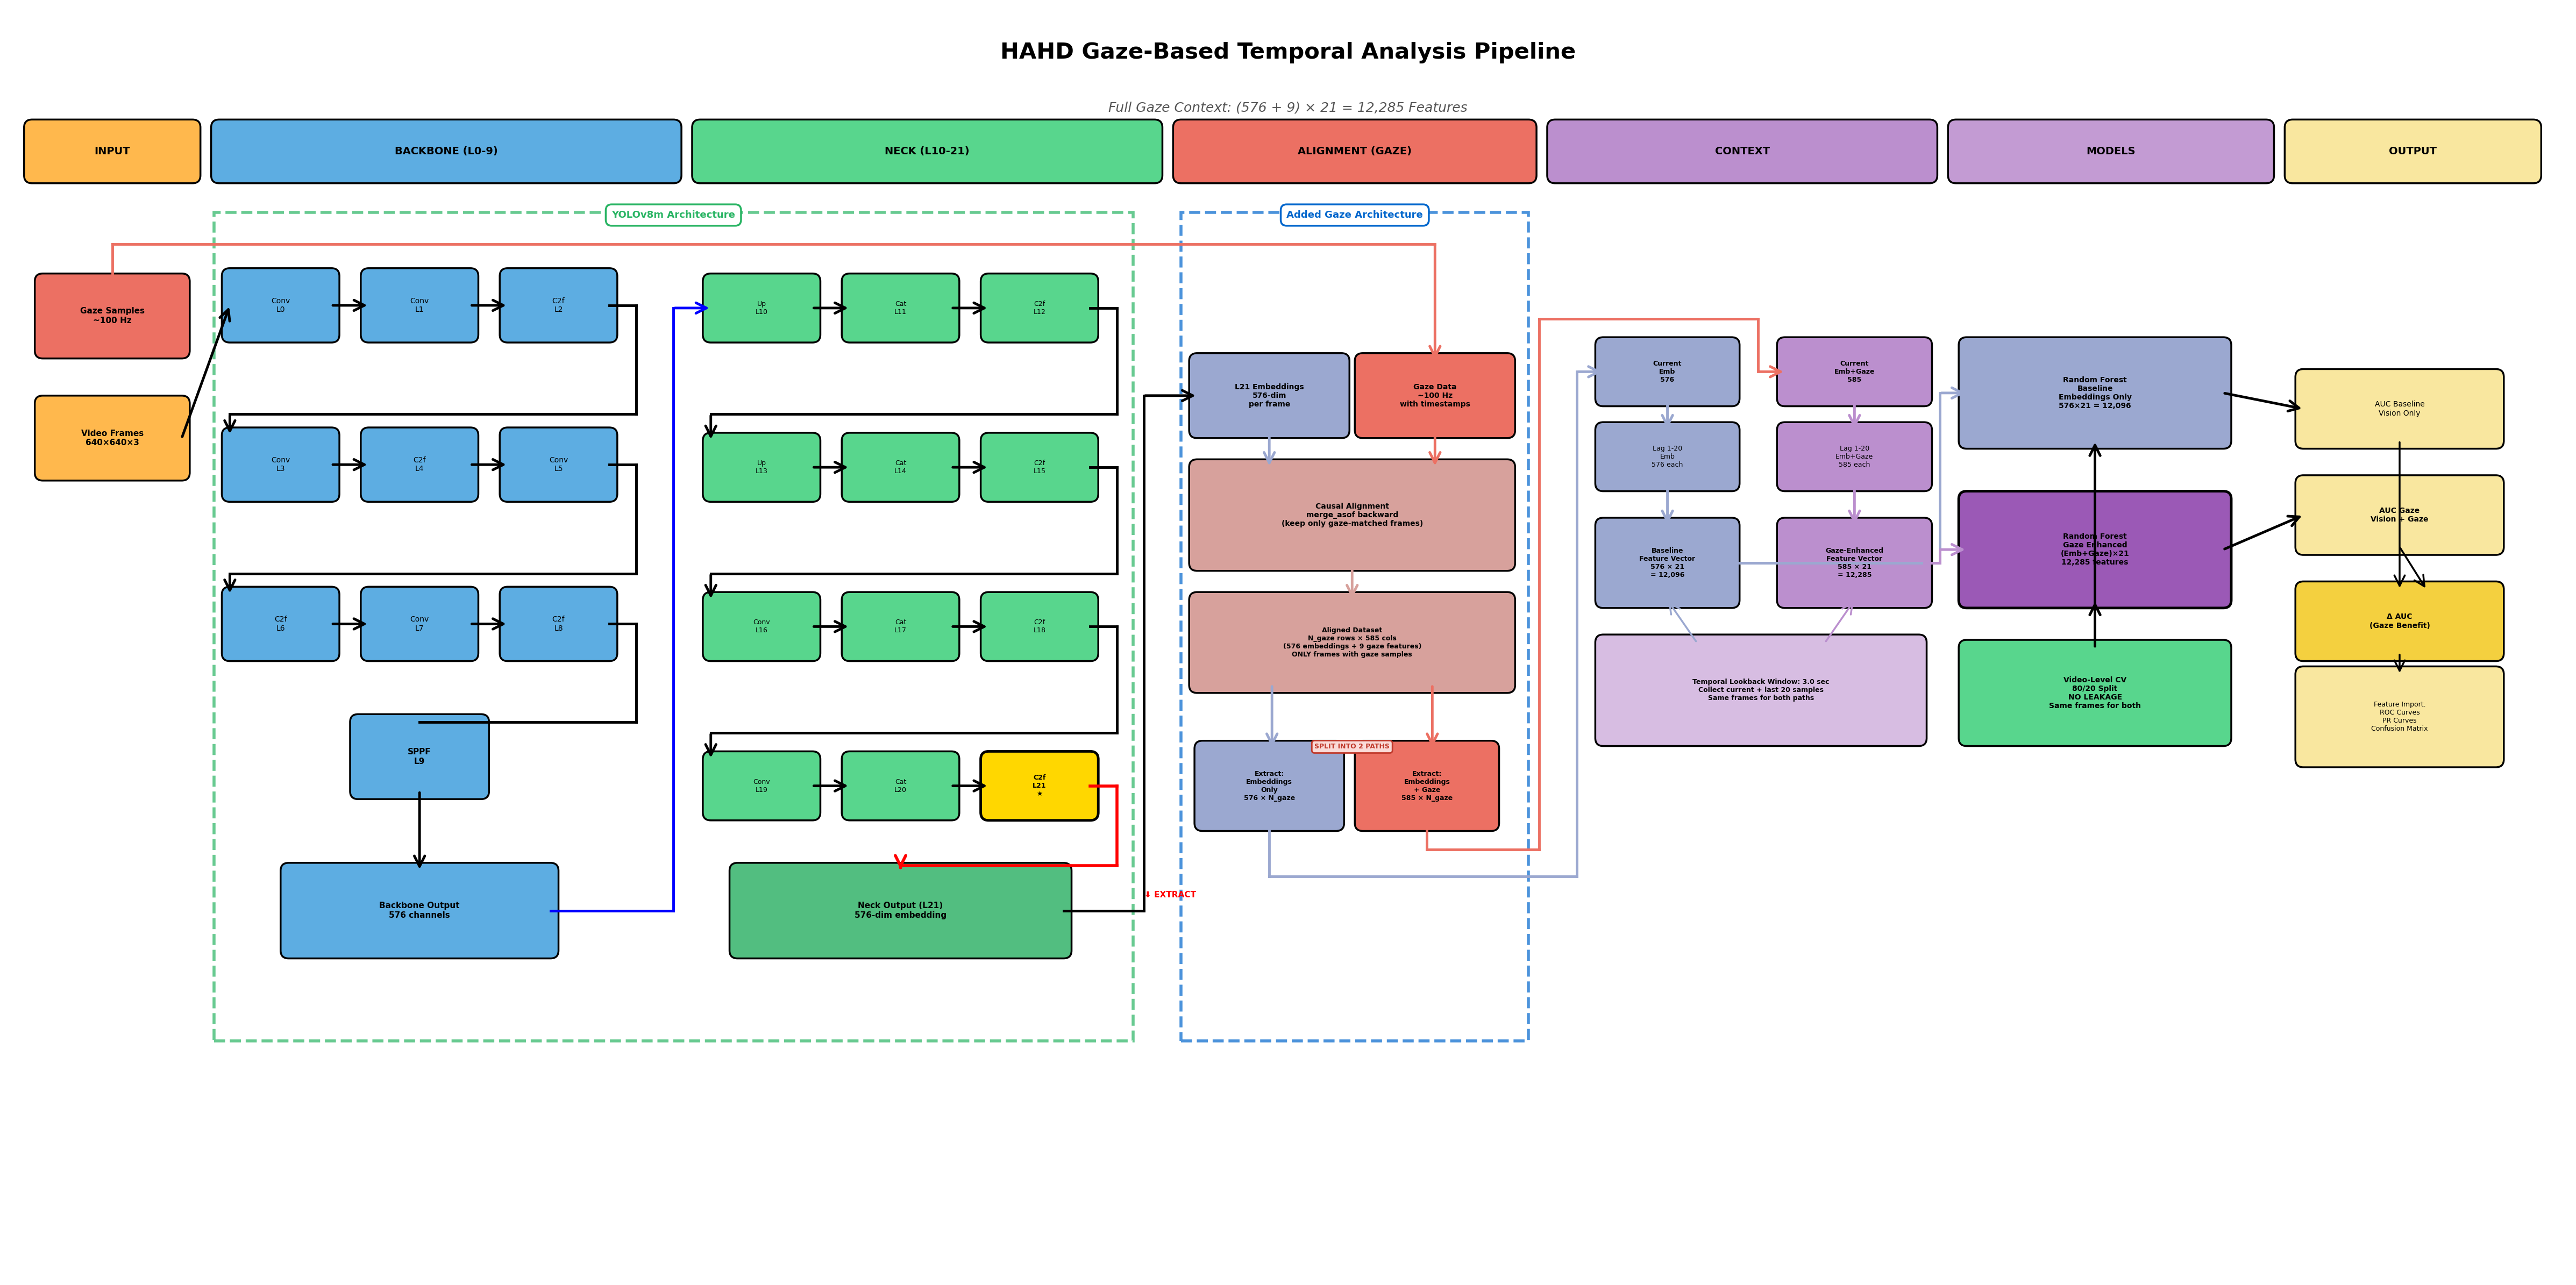

In [2]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch, Rectangle
import numpy as np

fig, ax = plt.subplots(1, 1, figsize=(48, 24))
ax.set_xlim(0, 48)
ax.set_ylim(0, 24)
ax.axis('off')

color_input = '#E5E7EB'
color_backbone = '#374151'
color_neck = '#6B7280'
color_gaze_processing = '#eb1572'
color_gaze_features = '#eb1572'
color_model = '#FDE8EF'
color_output = '#1A1A1A'
color_gaze_input = '#eb1572'

def create_box(ax, x, y, width, height, text, color, fontsize=11, fontweight='normal', edgecolor='black', linewidth=2.5):
    box = FancyBboxPatch((x, y), width, height, 
                         boxstyle="round,pad=0.15", 
                         edgecolor=edgecolor, 
                         facecolor=color, 
                         linewidth=linewidth)
    ax.add_patch(box)
    ax.text(x + width/2, y + height/2, text, 
           ha='center', va='center', 
           fontsize=fontsize, fontweight=fontweight)
    
    return {
        'x': x, 'y': y, 'width': width, 'height': height,
        'left': x, 'right': x + width,
        'bottom': y, 'top': y + height,
        'center_x': x + width/2, 'center_y': y + height/2
    }

def arrow(ax, x1, y1, x2, y2, color='black', width=3.5, style='-'):
    arr = FancyArrowPatch((x1, y1), (x2, y2),
                         arrowstyle='->', mutation_scale=35, 
                         linewidth=width, color=color, linestyle=style,
                         zorder=1)
    ax.add_patch(arr)

def path_arrow(ax, points, color='black', width=3.5, style='-'):
    for i in range(len(points)-1):
        if i == len(points)-2:
            arrow(ax, points[i][0], points[i][1], points[i+1][0], points[i+1][1], color, width, style)
        else:
            ax.plot([points[i][0], points[i+1][0]], [points[i][1], points[i+1][1]], 
                   color=color, linewidth=width, linestyle=style, zorder=1)

ax.text(24, 23.0, 'HAHD Gaze-Based Temporal Analysis Pipeline', 
        ha='center', fontsize=30, fontweight='bold')
ax.text(24, 22.0, 'Full Gaze Context: (576 + 9) × 21 = 12,285 Features', 
        ha='center', fontsize=18, style='italic', color='#6B7280')

create_box(ax, 0.5, 20.8, 3.0, 0.9, 'INPUT', color_input, fontsize=14, fontweight='bold')
create_box(ax, 4.0, 20.8, 8.5, 0.9, 'BACKBONE (L0-9)', color_backbone, fontsize=14, fontweight='bold')
create_box(ax, 13.0, 20.8, 8.5, 0.9, 'NECK (L10-21)', color_neck, fontsize=14, fontweight='bold')
create_box(ax, 22.0, 20.8, 6.5, 0.9, 'ALIGNMENT (GAZE)', color_gaze_input, fontsize=14, fontweight='bold')
create_box(ax, 29.0, 20.8, 7.0, 0.9, 'CONTEXT', color_gaze_features, fontsize=14, fontweight='bold')
create_box(ax, 36.5, 20.8, 5.8, 0.9, 'MODELS', color_model, fontsize=14, fontweight='bold')
create_box(ax, 42.8, 20.8, 4.5, 0.9, 'OUTPUT', color_output, fontsize=14, fontweight='bold')

yolo_box = Rectangle((3.9, 4.5), 17.2, 15.6, 
                      linewidth=4, edgecolor='#374151', 
                      facecolor='none', linestyle='--', alpha=0.7)
ax.add_patch(yolo_box)
ax.text(12.5, 20.0, 'YOLOv8m Architecture', ha='center', fontsize=13, 
        fontweight='bold', color='#374151',
        bbox=dict(boxstyle='round,pad=0.6', facecolor='white', 
                 edgecolor='#374151', linewidth=2.5))

gaze_arch_box = Rectangle((22.0, 4.5), 6.5, 15.6, 
                          linewidth=4, edgecolor='#eb1572', 
                          facecolor='none', linestyle='--', alpha=0.7)
ax.add_patch(gaze_arch_box)
ax.text(25.25, 20.0, 'Added Gaze Architecture', ha='center', fontsize=13, 
        fontweight='bold', color='#eb1572',
        bbox=dict(boxstyle='round,pad=0.6', facecolor='white', 
                 edgecolor='#eb1572', linewidth=2.5))

input_gaze = create_box(ax, 0.7, 17.5, 2.6, 1.3, 'Gaze Samples\n~100 Hz', 
                       color_gaze_input, fontsize=11, fontweight='bold')
input_video = create_box(ax, 0.7, 15.2, 2.6, 1.3, 'Video Frames\n640×640×3', 
                        color_input, fontsize=11, fontweight='bold')

bb = []

bb.append(create_box(ax, 4.2, 17.8, 1.9, 1.1, 'Conv\nL0', color_backbone, fontsize=10))
bb.append(create_box(ax, 6.8, 17.8, 1.9, 1.1, 'Conv\nL1', color_backbone, fontsize=10))
bb.append(create_box(ax, 9.4, 17.8, 1.9, 1.1, 'C2f\nL2', color_backbone, fontsize=10))

bb.append(create_box(ax, 4.2, 14.8, 1.9, 1.1, 'Conv\nL3', color_backbone, fontsize=10))
bb.append(create_box(ax, 6.8, 14.8, 1.9, 1.1, 'C2f\nL4', color_backbone, fontsize=10))
bb.append(create_box(ax, 9.4, 14.8, 1.9, 1.1, 'Conv\nL5', color_backbone, fontsize=10))

bb.append(create_box(ax, 4.2, 11.8, 1.9, 1.1, 'C2f\nL6', color_backbone, fontsize=10))
bb.append(create_box(ax, 6.8, 11.8, 1.9, 1.1, 'Conv\nL7', color_backbone, fontsize=10))
bb.append(create_box(ax, 9.4, 11.8, 1.9, 1.1, 'C2f\nL8', color_backbone, fontsize=10))

bb_l9 = create_box(ax, 6.6, 9.2, 2.3, 1.3, 'SPPF\nL9', color_backbone, fontsize=11, fontweight='bold')
bb_out = create_box(ax, 5.3, 6.2, 4.9, 1.5, 'Backbone Output\n576 channels', 
                   color_backbone, fontsize=11, fontweight='bold')

arrow(ax, input_video['right'], input_video['center_y'], bb[0]['left'], bb[0]['center_y'], 'black', 3.5)
arrow(ax, bb[0]['right'], bb[0]['center_y'], bb[1]['left'], bb[1]['center_y'], 'black', 3.5)
arrow(ax, bb[1]['right'], bb[1]['center_y'], bb[2]['left'], bb[2]['center_y'], 'black', 3.5)

path_arrow(ax, [(bb[2]['right'], bb[2]['center_y']), 
                (bb[2]['right'] + 0.5, bb[2]['center_y']),
                (bb[2]['right'] + 0.5, 16.3),
                (bb[3]['left'], 16.3),
                (bb[3]['left'], bb[3]['top'])], 'black', 3.5)

arrow(ax, bb[3]['right'], bb[3]['center_y'], bb[4]['left'], bb[4]['center_y'], 'black', 3.5)
arrow(ax, bb[4]['right'], bb[4]['center_y'], bb[5]['left'], bb[5]['center_y'], 'black', 3.5)

path_arrow(ax, [(bb[5]['right'], bb[5]['center_y']),
                (bb[5]['right'] + 0.5, bb[5]['center_y']),
                (bb[5]['right'] + 0.5, 13.3),
                (bb[6]['left'], 13.3),
                (bb[6]['left'], bb[6]['top'])], 'black', 3.5)

arrow(ax, bb[6]['right'], bb[6]['center_y'], bb[7]['left'], bb[7]['center_y'], 'black', 3.5)
arrow(ax, bb[7]['right'], bb[7]['center_y'], bb[8]['left'], bb[8]['center_y'], 'black', 3.5)

path_arrow(ax, [(bb[8]['right'], bb[8]['center_y']),
                (bb[8]['right'] + 0.5, bb[8]['center_y']),
                (bb[8]['right'] + 0.5, 10.5),
                (bb_l9['center_x'], 10.5),
                (bb_l9['center_x'], bb_l9['top'])], 'black', 3.5)

arrow(ax, bb_l9['center_x'], bb_l9['bottom'], bb_out['center_x'], bb_out['top'], 'black', 3.5)

nk = []

nk.append(create_box(ax, 13.2, 17.8, 1.9, 1.0, 'Up\nL10', color_neck, fontsize=9))
nk.append(create_box(ax, 15.8, 17.8, 1.9, 1.0, 'Cat\nL11', color_neck, fontsize=9))
nk.append(create_box(ax, 18.4, 17.8, 1.9, 1.0, 'C2f\nL12', color_neck, fontsize=9))

nk.append(create_box(ax, 13.2, 14.8, 1.9, 1.0, 'Up\nL13', color_neck, fontsize=9))
nk.append(create_box(ax, 15.8, 14.8, 1.9, 1.0, 'Cat\nL14', color_neck, fontsize=9))
nk.append(create_box(ax, 18.4, 14.8, 1.9, 1.0, 'C2f\nL15', color_neck, fontsize=9))

nk.append(create_box(ax, 13.2, 11.8, 1.9, 1.0, 'Conv\nL16', color_neck, fontsize=9))
nk.append(create_box(ax, 15.8, 11.8, 1.9, 1.0, 'Cat\nL17', color_neck, fontsize=9))
nk.append(create_box(ax, 18.4, 11.8, 1.9, 1.0, 'C2f\nL18', color_neck, fontsize=9))

nk.append(create_box(ax, 13.2, 8.8, 1.9, 1.0, 'Conv\nL19', color_neck, fontsize=9))
nk.append(create_box(ax, 15.8, 8.8, 1.9, 1.0, 'Cat\nL20', color_neck, fontsize=9))
nk.append(create_box(ax, 18.4, 8.8, 1.9, 1.0, 'C2f\nL21\n★', '#eb1572', fontsize=9, 
                fontweight='bold', linewidth=3.5))

nk_out = create_box(ax, 13.7, 6.2, 6.1, 1.5, 'Neck Output (L21)\n576-dim embedding', 
                   '#6B7280', fontsize=11, fontweight='bold')

path_arrow(ax, [(bb_out['right'], bb_out['center_y']),
                (12.5, bb_out['center_y']),
                (12.5, nk[0]['center_y']),
                (nk[0]['left'], nk[0]['center_y'])], '#374151', 3.5)

arrow(ax, nk[0]['right'], nk[0]['center_y'], nk[1]['left'], nk[1]['center_y'], 'black', 3.5)
arrow(ax, nk[1]['right'], nk[1]['center_y'], nk[2]['left'], nk[2]['center_y'], 'black', 3.5)

path_arrow(ax, [(nk[2]['right'], nk[2]['center_y']),
                (nk[2]['right'] + 0.5, nk[2]['center_y']),
                (nk[2]['right'] + 0.5, 16.3),
                (nk[3]['left'], 16.3),
                (nk[3]['left'], nk[3]['top'])], 'black', 3.5)

arrow(ax, nk[3]['right'], nk[3]['center_y'], nk[4]['left'], nk[4]['center_y'], 'black', 3.5)
arrow(ax, nk[4]['right'], nk[4]['center_y'], nk[5]['left'], nk[5]['center_y'], 'black', 3.5)

path_arrow(ax, [(nk[5]['right'], nk[5]['center_y']),
                (nk[5]['right'] + 0.5, nk[5]['center_y']),
                (nk[5]['right'] + 0.5, 13.3),
                (nk[6]['left'], 13.3),
                (nk[6]['left'], nk[6]['top'])], 'black', 3.5)

arrow(ax, nk[6]['right'], nk[6]['center_y'], nk[7]['left'], nk[7]['center_y'], 'black', 3.5)
arrow(ax, nk[7]['right'], nk[7]['center_y'], nk[8]['left'], nk[8]['center_y'], 'black', 3.5)

path_arrow(ax, [(nk[8]['right'], nk[8]['center_y']),
                (nk[8]['right'] + 0.5, nk[8]['center_y']),
                (nk[8]['right'] + 0.5, 10.3),
                (nk[9]['left'], 10.3),
                (nk[9]['left'], nk[9]['top'])], 'black', 3.5)

arrow(ax, nk[9]['right'], nk[9]['center_y'], nk[10]['left'], nk[10]['center_y'], 'black', 3.5)
arrow(ax, nk[10]['right'], nk[10]['center_y'], nk[11]['left'], nk[11]['center_y'], 'black', 3.5)

path_arrow(ax, [(nk[11]['right'], nk[11]['center_y']),
                (nk[11]['right'] + 0.5, nk[11]['center_y']),
                (nk[11]['right'] + 0.5, 7.8),
                (nk_out['center_x'], 7.8),
                (nk_out['center_x'], nk_out['top'])], '#eb1572', 4)

ax.text(nk[11]['right'] + 1.5, 7.2, '⬇ EXTRACT', ha='center', fontsize=11, fontweight='bold', color='#eb1572')

gz_emb = create_box(ax, 22.3, 16.0, 2.7, 1.3, 'L21 Embeddings\n576-dim\nper frame', 
                   '#9CA3AF', fontsize=10, fontweight='bold')
gz_data = create_box(ax, 25.4, 16.0, 2.7, 1.3, 'Gaze Data\n~100 Hz\nwith timestamps', 
                    color_gaze_input, fontsize=10, fontweight='bold')

gz_merge = create_box(ax, 22.3, 13.5, 5.8, 1.8, 'Causal Alignment\nmerge_asof backward\n(keep only gaze-matched frames)', 
                     '#FDE8EF', fontsize=10, fontweight='bold')

gz_aligned = create_box(ax, 22.3, 11.2, 5.8, 1.6, 'Aligned Dataset\nN_gaze rows × 585 cols\n(576 embeddings + 9 gaze features)\nONLY frames with gaze samples', 
                       '#FDE8EF', fontsize=9, fontweight='bold')

gz_emb_only = create_box(ax, 22.4, 8.6, 2.5, 1.4, 'Extract:\nEmbeddings\nOnly\n576 × N_gaze', 
                        '#9CA3AF', fontsize=9, fontweight='bold')
gz_emb_gaze = create_box(ax, 25.4, 8.6, 2.4, 1.4, 'Extract:\nEmbeddings\n+ Gaze\n585 × N_gaze', 
                        color_gaze_input, fontsize=9, fontweight='bold')

path_arrow(ax, [(nk_out['right'], nk_out['center_y']),
                (21.3, nk_out['center_y']),
                (21.3, gz_emb['center_y']),
                (gz_emb['left'], gz_emb['center_y'])], 'black', 3.5)

path_arrow(ax, [(input_gaze['center_x'], input_gaze['top']),
                (input_gaze['center_x'], 19.5),
                (gz_data['center_x'], 19.5),
                (gz_data['center_x'], gz_data['top'])], color_gaze_input, 3.5)

arrow(ax, gz_emb['center_x'], gz_emb['bottom'], gz_emb['center_x'], gz_merge['top'], '#9CA3AF', 3.5)
arrow(ax, gz_data['center_x'], gz_data['bottom'], gz_data['center_x'], gz_merge['top'], color_gaze_input, 3.5)

arrow(ax, gz_merge['center_x'], gz_merge['bottom'], gz_merge['center_x'], gz_aligned['top'], '#FDE8EF', 3.5)

arrow(ax, gz_aligned['center_x'] - 1.5, gz_aligned['bottom'], gz_aligned['center_x'] - 1.5, gz_emb_only['top'], '#9CA3AF', 3.5)
arrow(ax, gz_aligned['center_x'] + 1.5, gz_aligned['bottom'], gz_aligned['center_x'] + 1.5, gz_emb_gaze['top'], color_gaze_input, 3.5)

ax.text(gz_aligned['center_x'], 10.0, 'SPLIT INTO 2 PATHS', ha='center', fontsize=9, 
        fontweight='bold', color='#eb1572',
        bbox=dict(boxstyle='round,pad=0.4', facecolor='#FDE8EF', 
                 edgecolor='#eb1572', linewidth=2))

tmp_base = []
tmp_base.append(create_box(ax, 29.9, 16.6, 2.4, 1.0, 'Current\nEmb\n576', 
                          '#9CA3AF', fontsize=9, fontweight='bold'))
tmp_base.append(create_box(ax, 29.9, 15.0, 2.4, 1.0, 'Lag 1-20\nEmb\n576 each', 
                          '#9CA3AF', fontsize=9))

tmp_base_concat = create_box(ax, 29.9, 12.8, 2.4, 1.4, 'Baseline\nFeature Vector\n576 × 21\n= 12,096', 
                            '#9CA3AF', fontsize=9, fontweight='bold')

tmp_gaze = []
tmp_gaze.append(create_box(ax, 33.3, 16.6, 2.6, 1.0, 'Current\nEmb+Gaze\n585', 
                          color_gaze_features, fontsize=9, fontweight='bold'))
tmp_gaze.append(create_box(ax, 33.3, 15.0, 2.6, 1.0, 'Lag 1-20\nEmb+Gaze\n585 each', 
                          color_gaze_features, fontsize=9))

tmp_gaze_concat = create_box(ax, 33.3, 12.8, 2.6, 1.4, 'Gaze-Enhanced\nFeature Vector\n585 × 21\n= 12,285', 
                             color_gaze_features, fontsize=9, fontweight='bold')

tmp_look = create_box(ax, 29.9, 10.2, 5.9, 1.8, 'Temporal Lookback Window: 3.0 sec\nCollect current + last 20 samples\nSame frames for both paths', 
                     '#FDE8EF', fontsize=9, fontweight='bold')

path_arrow(ax, [(gz_emb_only['center_x'], gz_emb_only['bottom']),
                (gz_emb_only['center_x'], gz_emb_only['bottom'] - 1.0),
                (tmp_base[0]['left'] - 0.5, gz_emb_only['bottom'] - 1.0),
                (tmp_base[0]['left'] - 0.5, tmp_base[0]['center_y']),
                (tmp_base[0]['left'], tmp_base[0]['center_y'])], '#9CA3AF', 3.5)

arrow(ax, tmp_base[0]['center_x'], tmp_base[0]['bottom'], tmp_base[1]['center_x'], tmp_base[1]['top'], '#9CA3AF', 3.5)
arrow(ax, tmp_base[1]['center_x'], tmp_base[1]['bottom'], tmp_base_concat['center_x'], tmp_base_concat['top'], '#9CA3AF', 3.5)

path_arrow(ax, [(gz_emb_gaze['center_x'], gz_emb_gaze['bottom']),
                (gz_emb_gaze['center_x'], gz_emb_gaze['bottom'] - 0.5),
                (28.7, gz_emb_gaze['bottom'] - 0.5),
                (28.7, tmp_base[0]['top'] + 0.5),
                (tmp_gaze[0]['left'] - 0.5, tmp_base[0]['top'] + 0.5),
                (tmp_gaze[0]['left'] - 0.5, tmp_gaze[0]['center_y']),
                (tmp_gaze[0]['left'], tmp_gaze[0]['center_y'])], color_gaze_input, 3.5)

arrow(ax, tmp_gaze[0]['center_x'], tmp_gaze[0]['bottom'], tmp_gaze[1]['center_x'], tmp_gaze[1]['top'], color_gaze_features, 3.5)
arrow(ax, tmp_gaze[1]['center_x'], tmp_gaze[1]['bottom'], tmp_gaze_concat['center_x'], tmp_gaze_concat['top'], color_gaze_features, 3.5)

arrow(ax, tmp_look['center_x'] - 1.2, tmp_look['top'], tmp_base_concat['center_x'], tmp_base_concat['bottom'], '#9CA3AF', 2.5)
arrow(ax, tmp_look['center_x'] + 1.2, tmp_look['top'], tmp_gaze_concat['center_x'], tmp_gaze_concat['bottom'], color_gaze_features, 2.5)

mdl_base = create_box(ax, 36.7, 15.8, 4.8, 1.8, 'Random Forest\nBaseline\nEmbeddings Only\n576×21 = 12,096', 
                     '#9CA3AF', fontsize=10, fontweight='bold')
mdl_gaze = create_box(ax, 36.7, 12.8, 4.8, 1.9, 'Random Forest\nGaze Enhanced\n(Emb+Gaze)×21\n12,285 features', 
                     '#eb1572', fontsize=10, fontweight='bold', linewidth=3.5)
mdl_cv = create_box(ax, 36.7, 10.2, 4.8, 1.7, 'Video-Level CV\n80/20 Split\nNO LEAKAGE\nSame frames for both', 
                   '#E5E7EB', fontsize=10, fontweight='bold')

path_arrow(ax, [(tmp_base_concat['right'], tmp_base_concat['center_y']),
                (36.2, tmp_base_concat['center_y']),
                (36.2, mdl_base['center_y']),
                (mdl_base['left'], mdl_base['center_y'])], '#9CA3AF', 3.5)

path_arrow(ax, [(tmp_gaze_concat['right'], tmp_gaze_concat['center_y']),
                (36.2, tmp_gaze_concat['center_y']),
                (36.2, mdl_gaze['center_y']),
                (mdl_gaze['left'], mdl_gaze['center_y'])], color_gaze_features, 3.5)

arrow(ax, mdl_cv['center_x'], mdl_cv['top'], mdl_gaze['center_x'], mdl_gaze['bottom'], 'black', 3.5)
arrow(ax, mdl_cv['center_x'], mdl_cv['top'] + 0.8, mdl_base['center_x'], mdl_base['bottom'], 'black', 3.5)

out = []
out.append(create_box(ax, 43.0, 15.8, 3.6, 1.2, 'AUC Baseline\nVision Only', color_output, fontsize=10))
out.append(create_box(ax, 43.0, 13.8, 3.6, 1.2, 'AUC Gaze\nVision + Gaze', color_output, fontsize=10, fontweight='bold'))
out.append(create_box(ax, 43.0, 11.8, 3.6, 1.2, 'Δ AUC\n(Gaze Benefit)', '#eb1572', fontsize=10, fontweight='bold'))
out.append(create_box(ax, 43.0, 9.8, 3.6, 1.6, 'Feature Import.\nROC Curves\nPR Curves\nConfusion Matrix', 
                     color_output, fontsize=9))

arrow(ax, mdl_base['right'], mdl_base['center_y'], out[0]['left'], out[0]['center_y'], 'black', 3.5)
arrow(ax, mdl_gaze['right'], mdl_gaze['center_y'], out[1]['left'], out[1]['center_y'], 'black', 3.5)

arrow(ax, out[0]['center_x'], out[0]['bottom'], out[2]['center_x'], out[2]['top'], 'black', 2.5)
arrow(ax, out[1]['center_x'], out[1]['bottom'], out[2]['center_x'] + 0.5, out[2]['top'], 'black', 2.5)
arrow(ax, out[2]['center_x'], out[2]['bottom'], out[3]['center_x'], out[3]['top'], 'black', 2.5)

plt.tight_layout()
plt.savefig('hahd_improved_pipeline.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

print("diagram updated successfully")


LOADING DATA - GAZE-BASED TEMPORAL STRUCTURE

loading embeddings: yolo_embeddings_fixed.csv
  embedding dimension: 576

loading hahd data: ../data/silver/csv/hahd_preprocessed_final.csv
  using 'time_since_start' for alignment

TEMPORAL ALIGNMENT WITH CAUSALITY
video fps: 36
causality enforced: gaze can only react to past frames

aligning gaze samples to video frames...

filtering out 13 videos with corrupted timestamps
processing 323 videos...

aligned 52,965 gaze samples to frames
  each row = 1 gaze sample with its frame embedding
  NO aggregation - all gaze samples preserved

alignment complete:
  total gaze samples: 52,965
  match rate: 92.5%

STARTING GAZE-BASED TEMPORAL ANALYSIS

approach: attention sequence modeling
  - each row = 1 gaze sample
  - includes embeddings from last 20 gazes within 3.0s
  - preserves all gaze samples (no aggregation)
  - causality enforced: gaze follows vision

CREATING GAZE-BASED TEMPORAL FEATURES

configuration:
  lookback window: 3.0 seconds
  m

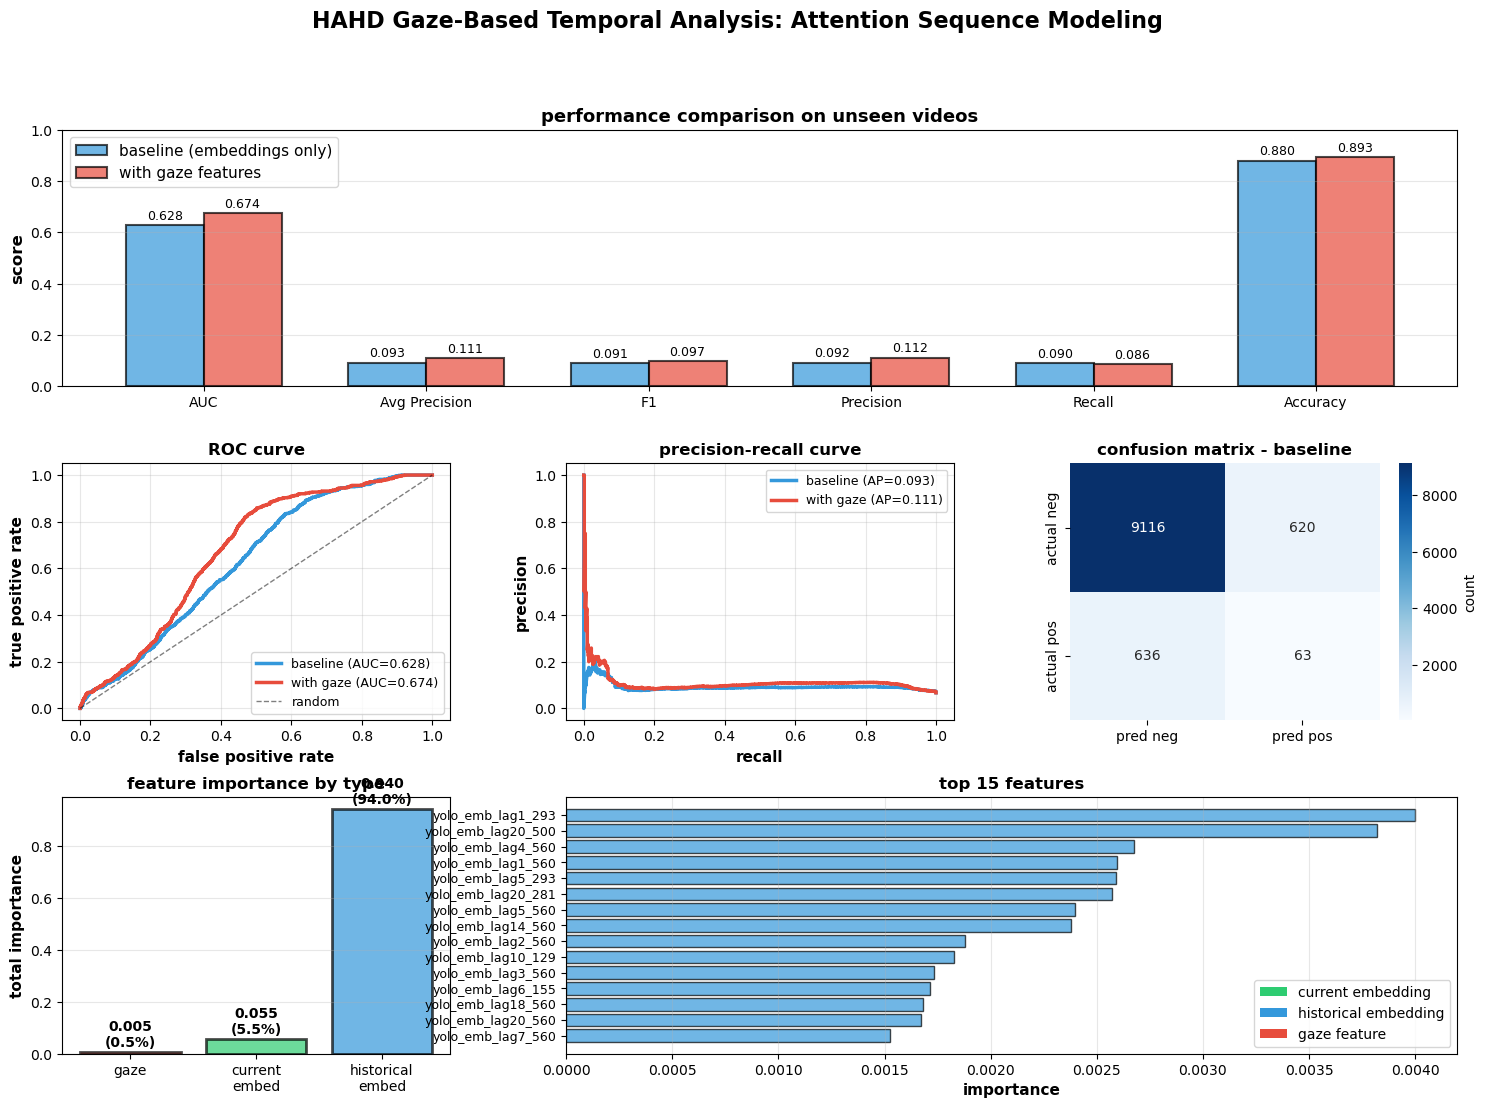


SAVING RESULTS
saved: hahd_gaze_sequence_metrics.csv
saved: hahd_gaze_sequence_feature_importance.csv

saving processed dataset with gaze sequences...
saved: hahd_gaze_sequence_dataset.csv
  shape: (52965, 12153)
  columns: 12153

ANALYSIS COMPLETE

key findings:
  baseline auc: 0.6282
  gaze auc: 0.6745
  improvement: +0.0463

this analysis uses:
  - gaze-based temporal structure (each row = 1 gaze)
  - attention sequence: current + last 20 gazes
  - lookback window: 3.0 seconds
  - causally-correct alignment (gaze follows vision)
  - proper video-level cv with NO data leakage


In [3]:
# Does 
"""
hahd gaze-based temporal analysis
each row = 1 gaze sample with historical attention sequence
enforces causality: gaze can only react to frames seen BEFORE
structure: current gaze + embeddings from last N gazes within lookback window
"""
#Does it also do this
"""
hahd gaze analysis with causally-correct temporal alignment
enforces causality: gaze can only react to frames seen BEFORE (not after)
prevents data leakage with video-level cross-validation
focuses on is_hazard_moment prediction only
FIXED: properly displays video frame numbers in diagnostics
TEMPORAL: uses sliding window aggregations over last N seconds
- looks at embeddings/gaze patterns over time (not just single frame)
- configurable window size (default: 2 seconds = 72 frames at 36 fps)
- computes mean, std, max, min over temporal window
"""
#and
"""
hahd gaze analysis with causally-correct temporal alignment
enforces causality: gaze can only react to frames seen BEFORE (not after)
prevents data leakage with video-level cross-validation
focuses on is_hazard_moment prediction only
FIXED: properly displays video frame numbers in diagnostics
"""

import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    roc_auc_score, accuracy_score, precision_score, recall_score, 
    f1_score, confusion_matrix, roc_curve, precision_recall_curve, 
    average_precision_score
)
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')


class GazeBasedTemporalAnalysis:
    """
    gaze-based temporal analysis
    each row = 1 gaze sample
    includes: current frame embedding + embeddings from last N gazes
    """
    
    def __init__(self, embeddings_csv, hahd_csv, video_fps=36):
        print(f"\n{'='*80}")
        print(f"LOADING DATA - GAZE-BASED TEMPORAL STRUCTURE")
        print(f"{'='*80}")
        
        self.video_fps = video_fps
        self.ms_per_frame = 1000.0 / video_fps
        
        print(f"\nloading embeddings: {embeddings_csv}")
        self.emb_df = pd.read_csv(embeddings_csv)
        
        emb_cols = [col for col in self.emb_df.columns if col.startswith('yolo_emb_')]
        self.embedding_dim = len(emb_cols)
        print(f"  embedding dimension: {self.embedding_dim}")
        
        if self.embedding_dim < 100:
            raise ValueError(f"embeddings broken! only {self.embedding_dim} dims")
        
        print(f"\nloading hahd data: {hahd_csv}")
        self.hahd_df = pd.read_csv(hahd_csv)
        
        if 'time_since_start' in self.hahd_df.columns:
            print(f"  using 'time_since_start' for alignment")
            self.timestamp_col = 'time_since_start'
        elif 'timestamp' in self.hahd_df.columns:
            print(f"  converting 'timestamp' to relative time per video...")
            self.hahd_df['time_since_start'] = self.hahd_df.groupby('video_id')['timestamp'].transform(
                lambda x: x - x.min()
            )
            self.timestamp_col = 'time_since_start'
        else:
            raise ValueError("no timestamp column found!")
        
        print(f"\n{'='*80}")
        print(f"TEMPORAL ALIGNMENT WITH CAUSALITY")
        print(f"{'='*80}")
        print(f"video fps: {video_fps}")
        print(f"causality enforced: gaze can only react to past frames")
        
        self.df_aligned = self._align_gaze_to_frames()
        
        if self.df_aligned.empty:
            raise ValueError("alignment failed - no matched data")
        
        print(f"\nalignment complete:")
        print(f"  total gaze samples: {len(self.df_aligned):,}")
        print(f"  match rate: {len(self.df_aligned)/len(self.hahd_df)*100:.1f}%")
        
        self.gaze_features = [
            'gaze_x', 'gaze_y', 'video_rel_x', 'video_rel_y',
            'gaze_velocity_x', 'gaze_velocity_y', 'gaze_speed',
            'gaze_acceleration_x', 'gaze_acceleration_y'
        ]
        self.gaze_features = [f for f in self.gaze_features if f in self.df_aligned.columns]
        
        self.target = 'is_hazard_moment'
    
    def _align_gaze_to_frames(self):
        """
        align each gaze sample to its corresponding frame embedding
        returns: one row per gaze sample (no aggregation)
        """
        print(f"\naligning gaze samples to video frames...")
        
        emb_prepared = self.emb_df.copy()
        emb_prepared['yolo_frame_timestamp'] = emb_prepared['frame_index'] * self.ms_per_frame
        emb_prepared = emb_prepared.sort_values(['video_id', 'yolo_frame_timestamp'])
        
        gaze_prepared = self.hahd_df.copy()
        gaze_prepared[self.timestamp_col] = gaze_prepared[self.timestamp_col].astype('float64')
        
        max_reasonable_time = 30000
        bad_videos = gaze_prepared.groupby('video_id')[self.timestamp_col].max()
        bad_videos = bad_videos[bad_videos > max_reasonable_time].index.tolist()
        
        if bad_videos:
            print(f"\nfiltering out {len(bad_videos)} videos with corrupted timestamps")
            gaze_prepared = gaze_prepared[~gaze_prepared['video_id'].isin(bad_videos)]
        
        gaze_prepared = gaze_prepared.dropna(subset=[self.timestamp_col, 'video_id'])
        gaze_prepared = gaze_prepared.reset_index(drop=True)
        emb_prepared = emb_prepared.reset_index(drop=True)
        
        print(f"processing {gaze_prepared['video_id'].nunique()} videos...")
        
        aligned_dfs = []
        
        for video_id in gaze_prepared['video_id'].unique():
            gaze_video = gaze_prepared[gaze_prepared['video_id'] == video_id].copy()
            emb_video = emb_prepared[emb_prepared['video_id'] == video_id].copy()
            
            if emb_video.empty:
                continue
            
            gaze_video = gaze_video.sort_values(self.timestamp_col).reset_index(drop=True)
            emb_video = emb_video.sort_values('yolo_frame_timestamp').reset_index(drop=True)
            
            aligned_video = pd.merge_asof(
                gaze_video,
                emb_video,
                left_on=self.timestamp_col,
                right_on='yolo_frame_timestamp',
                direction='backward',
                tolerance=1000,
                suffixes=('', '_emb')
            )
            
            aligned_video = aligned_video.dropna(subset=['frame_index'])
            aligned_dfs.append(aligned_video)
        
        if not aligned_dfs:
            return pd.DataFrame()
        
        aligned_df = pd.concat(aligned_dfs, ignore_index=True)
        
        print(f"\naligned {len(aligned_df):,} gaze samples to frames")
        print(f"  each row = 1 gaze sample with its frame embedding")
        print(f"  NO aggregation - all gaze samples preserved")
        
        return aligned_df
    
    def create_gaze_sequence_features(self, lookback_seconds=2.0, max_lags=10):
        """
        create temporal features based on gaze attention sequence
        for each gaze sample, include embeddings from previous gazes
        """
        print(f"\n{'='*80}")
        print(f"CREATING GAZE-BASED TEMPORAL FEATURES")
        print(f"{'='*80}")
        
        lookback_ms = lookback_seconds * 1000
        
        print(f"\nconfiguration:")
        print(f"  lookback window: {lookback_seconds} seconds")
        print(f"  max lag positions: {max_lags}")
        print(f"  structure: current gaze + last {max_lags} gazes within {lookback_seconds}s")
        
        embedding_cols = [col for col in self.df_aligned.columns if col.startswith('yolo_emb_')]
        
        print(f"\nprocessing {self.df_aligned['video_id'].nunique()} videos...")
        
        temporal_rows = []
        
        for video_id in self.df_aligned['video_id'].unique():
            video_df = self.df_aligned[self.df_aligned['video_id'] == video_id].copy()
            video_df = video_df.sort_values(self.timestamp_col).reset_index(drop=True)
            
            for idx in range(len(video_df)):
                current_row = video_df.iloc[idx]
                current_time = current_row[self.timestamp_col]
                
                row_data = {}
                
                for col in video_df.columns:
                    if col not in embedding_cols:
                        row_data[col] = current_row[col]
                
                for i, emb_col in enumerate(embedding_cols):
                    row_data[f'yolo_emb_current_{i}'] = current_row[emb_col]
                
                lookback_start = current_time - lookback_ms
                past_gazes = video_df[(video_df[self.timestamp_col] >= lookback_start) & 
                                     (video_df[self.timestamp_col] < current_time)]
                
                past_gazes = past_gazes.sort_values(self.timestamp_col, ascending=False)
                
                for lag in range(1, max_lags + 1):
                    if lag <= len(past_gazes):
                        lag_row = past_gazes.iloc[lag - 1]
                        for i, emb_col in enumerate(embedding_cols):
                            row_data[f'yolo_emb_lag{lag}_{i}'] = lag_row[emb_col]
                    else:
                        for i in range(self.embedding_dim):
                            row_data[f'yolo_emb_lag{lag}_{i}'] = 0.0
                
                row_data['num_gazes_in_window'] = len(past_gazes)
                
                temporal_rows.append(row_data)
        
        self.df_temporal = pd.DataFrame(temporal_rows)
        
        self.current_emb_features = [f'yolo_emb_current_{i}' for i in range(self.embedding_dim)]
        self.lag_emb_features = []
        for lag in range(1, max_lags + 1):
            self.lag_emb_features.extend([f'yolo_emb_lag{lag}_{i}' for i in range(self.embedding_dim)])
        
        self.all_emb_features = self.current_emb_features + self.lag_emb_features
        
        print(f"\ntemporal features created:")
        print(f"  total samples: {len(self.df_temporal):,}")
        print(f"  current frame embeddings: {len(self.current_emb_features)} features")
        print(f"  historical embeddings: {len(self.lag_emb_features)} features ({max_lags} lags × {self.embedding_dim} dims)")
        print(f"  total embedding features: {len(self.all_emb_features)}")
        print(f"  gaze features: {len(self.gaze_features)}")
        
        avg_gazes = self.df_temporal['num_gazes_in_window'].mean()
        print(f"\naverage gazes in {lookback_seconds}s window: {avg_gazes:.1f}")
        print(f"  min: {self.df_temporal['num_gazes_in_window'].min()}")
        print(f"  max: {self.df_temporal['num_gazes_in_window'].max()}")
        
        has_full_history = (self.df_temporal['num_gazes_in_window'] >= max_lags).sum()
        print(f"\nsamples with full history ({max_lags}+ gazes): {has_full_history:,} / {len(self.df_temporal):,}")
        print(f"  ({has_full_history/len(self.df_temporal)*100:.1f}%)")
    
    def create_video_level_split(self, test_split=0.2, random_state=42):
        """
        split data at video level to prevent leakage
        """
        print(f"\n{'='*80}")
        print(f"VIDEO-LEVEL SPLIT")
        print(f"{'='*80}")
        
        all_features = self.all_emb_features + self.gaze_features + [self.target, 'video_id']
        df_clean = self.df_temporal[all_features].copy().dropna()
        
        unique_videos = df_clean['video_id'].unique()
        n_test_videos = int(len(unique_videos) * test_split)
        
        np.random.seed(random_state)
        test_videos = np.random.choice(unique_videos, size=n_test_videos, replace=False)
        train_videos = [v for v in unique_videos if v not in test_videos]
        
        print(f"\nvideo split:")
        print(f"  total videos: {len(unique_videos)}")
        print(f"  train videos: {len(train_videos)} ({len(train_videos)/len(unique_videos)*100:.1f}%)")
        print(f"  test videos: {len(test_videos)} ({len(test_videos)/len(unique_videos)*100:.1f}%)")
        print(f"  overlap: 0 videos (NO LEAKAGE)")
        
        train_mask = df_clean['video_id'].isin(train_videos)
        test_mask = df_clean['video_id'].isin(test_videos)
        
        self.X_emb_train = df_clean.loc[train_mask, self.all_emb_features]
        self.X_emb_test = df_clean.loc[test_mask, self.all_emb_features]
        self.X_gaze_train = df_clean.loc[train_mask, self.gaze_features]
        self.X_gaze_test = df_clean.loc[test_mask, self.gaze_features]
        self.y_train = df_clean.loc[train_mask, self.target]
        self.y_test = df_clean.loc[test_mask, self.target]
        
        self.X_combined_train = pd.concat([self.X_emb_train, self.X_gaze_train], axis=1)
        self.X_combined_test = pd.concat([self.X_emb_test, self.X_gaze_test], axis=1)
        
        print(f"\nfeature counts:")
        print(f"  baseline (embeddings only): {len(self.all_emb_features):,} features")
        print(f"  with gaze: {len(self.all_emb_features) + len(self.gaze_features):,} features")
        
        print(f"\ntarget distribution:")
        print(f"  train: {len(self.y_train):,} samples ({self.y_train.mean()*100:.1f}% hazard)")
        print(f"  test:  {len(self.y_test):,} samples ({self.y_test.mean()*100:.1f}% hazard)")
        
        return train_videos, test_videos
    
    def calculate_comprehensive_metrics(self, y_true, y_pred_proba, y_pred_class):
        """
        calculate all classification metrics
        """
        metrics = {}
        
        metrics['auc'] = roc_auc_score(y_true, y_pred_proba)
        metrics['average_precision'] = average_precision_score(y_true, y_pred_proba)
        metrics['accuracy'] = accuracy_score(y_true, y_pred_class)
        metrics['precision'] = precision_score(y_true, y_pred_class, zero_division=0)
        metrics['recall'] = recall_score(y_true, y_pred_class, zero_division=0)
        metrics['f1'] = f1_score(y_true, y_pred_class, zero_division=0)
        
        tn, fp, fn, tp = confusion_matrix(y_true, y_pred_class).ravel()
        metrics['true_negative'] = tn
        metrics['false_positive'] = fp
        metrics['false_negative'] = fn
        metrics['true_positive'] = tp
        
        metrics['specificity'] = tn / (tn + fp) if (tn + fp) > 0 else 0
        metrics['sensitivity'] = tp / (tp + fn) if (tp + fn) > 0 else 0
        
        return metrics
    
    def train_and_evaluate(self):
        """
        train models and evaluate on held-out videos
        """
        print(f"\n{'='*80}")
        print(f"TRAINING MODELS")
        print(f"{'='*80}")
        
        rf_params = {
            'n_estimators': 100,
            'max_depth': 10,
            'min_samples_split': 50,
            'min_samples_leaf': 20,
            'class_weight': 'balanced',
            'random_state': 42,
            'n_jobs': -1
        }
        
        print(f"\ntraining baseline model (embeddings only)...")
        self.model_base = RandomForestClassifier(**rf_params)
        self.model_base.fit(self.X_emb_train, self.y_train)
        
        print(f"training gaze-enhanced model (embeddings + gaze)...")
        self.model_gaze = RandomForestClassifier(**rf_params)
        self.model_gaze.fit(self.X_combined_train, self.y_train)
        
        print(f"\nevaluating on held-out test videos...")
        self.base_pred_proba = self.model_base.predict_proba(self.X_emb_test)[:, 1]
        self.base_pred_class = self.model_base.predict(self.X_emb_test)
        
        self.gaze_pred_proba = self.model_gaze.predict_proba(self.X_combined_test)[:, 1]
        self.gaze_pred_class = self.model_gaze.predict(self.X_combined_test)
        
        self.base_metrics = self.calculate_comprehensive_metrics(
            self.y_test, self.base_pred_proba, self.base_pred_class
        )
        
        self.gaze_metrics = self.calculate_comprehensive_metrics(
            self.y_test, self.gaze_pred_proba, self.gaze_pred_class
        )
        
        self.print_results()
        self.analyze_feature_importance()
    
    def print_results(self):
        """
        print comprehensive results
        """
        print(f"\n{'='*80}")
        print(f"COMPREHENSIVE METRICS (ON UNSEEN VIDEOS)")
        print(f"{'='*80}")
        
        print(f"\n{'metric':<30} {'baseline':>15} {'with gaze':>15} {'change':>15}")
        print(f"{'-'*80}")
        
        metrics_to_show = [
            ('auc', 'AUC-ROC'),
            ('average_precision', 'Average Precision'),
            ('accuracy', 'Accuracy'),
            ('precision', 'Precision'),
            ('recall', 'Recall'),
            ('f1', 'F1 Score'),
            ('specificity', 'Specificity'),
        ]
        
        for key, label in metrics_to_show:
            base_val = self.base_metrics[key]
            gaze_val = self.gaze_metrics[key]
            diff = gaze_val - base_val
            print(f"{label:<30} {base_val:>15.4f} {gaze_val:>15.4f} {diff:>15.4f}")
        
        print(f"\nconfusion matrix - baseline model:")
        print(f"  TN: {self.base_metrics['true_negative']:>6,}  FP: {self.base_metrics['false_positive']:>6,}")
        print(f"  FN: {self.base_metrics['false_negative']:>6,}  TP: {self.base_metrics['true_positive']:>6,}")
        
        print(f"\nconfusion matrix - gaze model:")
        print(f"  TN: {self.gaze_metrics['true_negative']:>6,}  FP: {self.gaze_metrics['false_positive']:>6,}")
        print(f"  FN: {self.gaze_metrics['false_negative']:>6,}  TP: {self.gaze_metrics['true_positive']:>6,}")
        
        auc_improvement = self.gaze_metrics['auc'] - self.base_metrics['auc']
        relative_improvement = (auc_improvement / self.base_metrics['auc']) * 100
        
        print(f"\n{'='*80}")
        print(f"GAZE BENEFIT ASSESSMENT")
        print(f"{'='*80}")
        print(f"\nauc improvement: {auc_improvement:+.4f} ({relative_improvement:+.2f}%)")
        
        if auc_improvement > 0.03:
            verdict = "SIGNIFICANT BENEFIT"
        elif auc_improvement > 0.01:
            verdict = "MODERATE BENEFIT"
        elif auc_improvement > 0:
            verdict = "MINIMAL BENEFIT"
        else:
            verdict = "NO BENEFIT"
        
        print(f"verdict: {verdict}")
    
    def analyze_feature_importance(self):
        """
        analyze feature importance from gaze model
        """
        print(f"\n{'='*80}")
        print(f"FEATURE IMPORTANCE ANALYSIS")
        print(f"{'='*80}")
        
        all_features_list = list(self.X_combined_train.columns)
        
        feature_types = []
        for feat in all_features_list:
            if 'yolo_emb_current' in feat:
                feature_types.append('current_embedding')
            elif 'yolo_emb_lag' in feat:
                feature_types.append('historical_embedding')
            elif any(gf in feat for gf in self.gaze_features):
                feature_types.append('gaze')
            else:
                feature_types.append('other')
        
        self.feature_importance = pd.DataFrame({
            'feature': all_features_list,
            'importance': self.model_gaze.feature_importances_,
            'type': feature_types
        }).sort_values('importance', ascending=False)
        
        print(f"\ntop 20 most important features:")
        for i, (_, row) in enumerate(self.feature_importance.head(20).iterrows(), 1):
            feat_name = row['feature'][:50] if len(row['feature']) > 50 else row['feature']
            print(f"  {i:2d}. {feat_name:50s} {row['importance']:.5f} [{row['type']}]")
        
        current_imp = self.feature_importance[self.feature_importance['type'] == 'current_embedding']['importance'].sum()
        historical_imp = self.feature_importance[self.feature_importance['type'] == 'historical_embedding']['importance'].sum()
        gaze_imp = self.feature_importance[self.feature_importance['type'] == 'gaze']['importance'].sum()
        
        print(f"\ntotal feature importance by type:")
        print(f"  current embeddings:     {current_imp:.4f} ({current_imp*100:.1f}%)")
        print(f"  historical embeddings:  {historical_imp:.4f} ({historical_imp*100:.1f}%)")
        print(f"  gaze features:          {gaze_imp:.4f} ({gaze_imp*100:.1f}%)")
        
        print(f"\ntop gaze features:")
        gaze_feats = self.feature_importance[self.feature_importance['type'] == 'gaze'].head(10)
        for i, (_, row) in enumerate(gaze_feats.iterrows(), 1):
            feat_name = row['feature'][:40] if len(row['feature']) > 40 else row['feature']
            print(f"  {i:2d}. {feat_name:40s} {row['importance']:.5f}")
    
    def visualize_results(self):
        """
        create comprehensive visualizations
        """
        print(f"\n{'='*80}")
        print(f"GENERATING VISUALIZATIONS")
        print(f"{'='*80}")
        
        fig = plt.figure(figsize=(18, 12))
        gs = fig.add_gridspec(3, 3, hspace=0.3, wspace=0.3)
        
        fig.suptitle('HAHD Gaze-Based Temporal Analysis: Attention Sequence Modeling', 
                     fontsize=16, fontweight='bold')
        
        ax_metrics = fig.add_subplot(gs[0, :])
        metrics_names = ['AUC', 'Avg Precision', 'F1', 'Precision', 'Recall', 'Accuracy']
        base_vals = [
            self.base_metrics['auc'],
            self.base_metrics['average_precision'],
            self.base_metrics['f1'],
            self.base_metrics['precision'],
            self.base_metrics['recall'],
            self.base_metrics['accuracy']
        ]
        gaze_vals = [
            self.gaze_metrics['auc'],
            self.gaze_metrics['average_precision'],
            self.gaze_metrics['f1'],
            self.gaze_metrics['precision'],
            self.gaze_metrics['recall'],
            self.gaze_metrics['accuracy']
        ]
        
        x = np.arange(len(metrics_names))
        width = 0.35
        
        bars1 = ax_metrics.bar(x - width/2, base_vals, width, label='baseline (embeddings only)', 
                               alpha=0.7, color='#1A1A1A', edgecolor='black', linewidth=1.5)
        bars2 = ax_metrics.bar(x + width/2, gaze_vals, width, label='with gaze features', 
                               alpha=0.7, color='#eb1572', edgecolor='black', linewidth=1.5)
        
        ax_metrics.set_ylabel('score', fontsize=12, fontweight='bold')
        ax_metrics.set_title('performance comparison on unseen videos', fontsize=13, fontweight='bold')
        ax_metrics.set_xticks(x)
        ax_metrics.set_xticklabels(metrics_names, rotation=0)
        ax_metrics.legend(fontsize=11)
        ax_metrics.set_ylim(0, 1.0)
        ax_metrics.grid(axis='y', alpha=0.3)
        
        for bars in [bars1, bars2]:
            for bar in bars:
                height = bar.get_height()
                ax_metrics.text(bar.get_x() + bar.get_width()/2., height + 0.01,
                               f'{height:.3f}', ha='center', va='bottom', fontsize=9)
        
        ax_roc = fig.add_subplot(gs[1, 0])
        fpr_base, tpr_base, _ = roc_curve(self.y_test, self.base_pred_proba)
        fpr_gaze, tpr_gaze, _ = roc_curve(self.y_test, self.gaze_pred_proba)
        
        ax_roc.plot(fpr_base, tpr_base, color='#1A1A1A', linewidth=2.5, 
                   label=f"baseline (AUC={self.base_metrics['auc']:.3f})")
        ax_roc.plot(fpr_gaze, tpr_gaze, color='#eb1572', linewidth=2.5, 
                   label=f"with gaze (AUC={self.gaze_metrics['auc']:.3f})")
        ax_roc.plot([0, 1], [0, 1], 'k--', linewidth=1, alpha=0.5, label='random')
        
        ax_roc.set_xlabel('false positive rate', fontsize=11, fontweight='bold')
        ax_roc.set_ylabel('true positive rate', fontsize=11, fontweight='bold')
        ax_roc.set_title('ROC curve', fontsize=12, fontweight='bold')
        ax_roc.legend(fontsize=9)
        ax_roc.grid(alpha=0.3)
        
        ax_pr = fig.add_subplot(gs[1, 1])
        precision_base, recall_base, _ = precision_recall_curve(self.y_test, self.base_pred_proba)
        precision_gaze, recall_gaze, _ = precision_recall_curve(self.y_test, self.gaze_pred_proba)
        
        ax_pr.plot(recall_base, precision_base, color='#1A1A1A', linewidth=2.5,
                  label=f"baseline (AP={self.base_metrics['average_precision']:.3f})")
        ax_pr.plot(recall_gaze, precision_gaze, color='#eb1572', linewidth=2.5,
                  label=f"with gaze (AP={self.gaze_metrics['average_precision']:.3f})")
        
        ax_pr.set_xlabel('recall', fontsize=11, fontweight='bold')
        ax_pr.set_ylabel('precision', fontsize=11, fontweight='bold')
        ax_pr.set_title('precision-recall curve', fontsize=12, fontweight='bold')
        ax_pr.legend(fontsize=9)
        ax_pr.grid(alpha=0.3)
        
        ax_conf = fig.add_subplot(gs[1, 2])
        
        conf_data = np.array([
            [self.base_metrics['true_negative'], self.base_metrics['false_positive']],
            [self.base_metrics['false_negative'], self.base_metrics['true_positive']]
        ])
        
        sns.heatmap(conf_data, annot=True, fmt='d', cmap='Blues', ax=ax_conf, 
                   xticklabels=['pred neg', 'pred pos'],
                   yticklabels=['actual neg', 'actual pos'],
                   cbar_kws={'label': 'count'})
        ax_conf.set_title('confusion matrix - baseline', fontsize=12, fontweight='bold')
        
        ax_feat_overall = fig.add_subplot(gs[2, 0])
        importance_by_type = self.feature_importance.groupby('type')['importance'].sum()
        
        current_imp = importance_by_type.get('current_embedding', 0)
        historical_imp = importance_by_type.get('historical_embedding', 0)
        gaze_imp = importance_by_type.get('gaze', 0)
        
        colors_type = ['#eb1572', '#eb1572', '#1A1A1A']
        bars = ax_feat_overall.bar(['gaze', 'current\nembed', 'historical\nembed'], 
                                   [gaze_imp, current_imp, historical_imp],
                                   color=colors_type, alpha=0.7, edgecolor='black', linewidth=2)
        ax_feat_overall.set_ylabel('total importance', fontsize=11, fontweight='bold')
        ax_feat_overall.set_title('feature importance by type', fontsize=12, fontweight='bold')
        ax_feat_overall.grid(axis='y', alpha=0.3)
        
        for bar in bars:
            height = bar.get_height()
            ax_feat_overall.text(bar.get_x() + bar.get_width()/2., height + 0.01,
                                f'{height:.3f}\n({height*100:.1f}%)',
                                ha='center', va='bottom', fontweight='bold', fontsize=10)
        
        ax_feat_top = fig.add_subplot(gs[2, 1:])
        top_features = self.feature_importance.head(15)
        colors_feat = []
        for t in top_features['type']:
            if t == 'gaze':
                colors_feat.append('#eb1572')
            elif t == 'current_embedding':
                colors_feat.append('#eb1572')
            else:
                colors_feat.append('#1A1A1A')
        
        bars = ax_feat_top.barh(range(len(top_features)), top_features['importance'],
                               color=colors_feat, alpha=0.7, edgecolor='black', linewidth=1)
        ax_feat_top.set_yticks(range(len(top_features)))
        ax_feat_top.set_yticklabels([f[:30] for f in top_features['feature']], fontsize=9)
        ax_feat_top.set_xlabel('importance', fontsize=11, fontweight='bold')
        ax_feat_top.set_title('top 15 features', fontsize=12, fontweight='bold')
        ax_feat_top.grid(axis='x', alpha=0.3)
        ax_feat_top.invert_yaxis()
        
        from matplotlib.patches import Patch
        legend_elements = [
            Patch(facecolor='#eb1572', label='current embedding'),
            Patch(facecolor='#1A1A1A', label='historical embedding'),
            Patch(facecolor='#eb1572', label='gaze feature')
        ]
        ax_feat_top.legend(handles=legend_elements, loc='lower right', fontsize=10)
        
        plt.savefig('hahd_gaze_sequence_analysis.png', dpi=300, bbox_inches='tight')
        print(f"\nsaved: hahd_gaze_sequence_analysis.png")
        plt.show()
    
    def save_results(self):
        """
        save detailed results to csv
        """
        print(f"\n{'='*80}")
        print(f"SAVING RESULTS")
        print(f"{'='*80}")
        
        metrics_df = pd.DataFrame({
            'metric': ['auc', 'average_precision', 'accuracy', 'precision', 'recall', 'f1', 
                      'specificity', 'sensitivity'],
            'baseline': [self.base_metrics['auc'], self.base_metrics['average_precision'],
                        self.base_metrics['accuracy'], self.base_metrics['precision'],
                        self.base_metrics['recall'], self.base_metrics['f1'],
                        self.base_metrics['specificity'], self.base_metrics['sensitivity']],
            'with_gaze': [self.gaze_metrics['auc'], self.gaze_metrics['average_precision'],
                         self.gaze_metrics['accuracy'], self.gaze_metrics['precision'],
                         self.gaze_metrics['recall'], self.gaze_metrics['f1'],
                         self.gaze_metrics['specificity'], self.gaze_metrics['sensitivity']]
        })
        metrics_df['improvement'] = metrics_df['with_gaze'] - metrics_df['baseline']
        
        metrics_df.to_csv('hahd_gaze_sequence_metrics.csv', index=False)
        print(f"saved: hahd_gaze_sequence_metrics.csv")
        
        self.feature_importance.to_csv('hahd_gaze_sequence_feature_importance.csv', index=False)
        print(f"saved: hahd_gaze_sequence_feature_importance.csv")
        
        print(f"\nsaving processed dataset with gaze sequences...")
        self.df_temporal.to_csv('hahd_gaze_sequence_dataset.csv', index=False)
        print(f"saved: hahd_gaze_sequence_dataset.csv")
        print(f"  shape: {self.df_temporal.shape}")
        print(f"  columns: {len(self.df_temporal.columns)}")
    
    def run_complete_analysis(self, lookback_seconds=2.0, max_lags=10):
        """
        run full gaze-based temporal analysis pipeline
        """
        print(f"\n{'='*80}")
        print(f"STARTING GAZE-BASED TEMPORAL ANALYSIS")
        print(f"{'='*80}")
        print(f"\napproach: attention sequence modeling")
        print(f"  - each row = 1 gaze sample")
        print(f"  - includes embeddings from last {max_lags} gazes within {lookback_seconds}s")
        print(f"  - preserves all gaze samples (no aggregation)")
        print(f"  - causality enforced: gaze follows vision")
        
        self.create_gaze_sequence_features(lookback_seconds=lookback_seconds, max_lags=max_lags)
        self.create_video_level_split()
        self.train_and_evaluate()
        self.visualize_results()
        self.save_results()
        
        print(f"\n{'='*80}")
        print(f"ANALYSIS COMPLETE")
        print(f"{'='*80}")
        print(f"\nkey findings:")
        auc_improvement = self.gaze_metrics['auc'] - self.base_metrics['auc']
        print(f"  baseline auc: {self.base_metrics['auc']:.4f}")
        print(f"  gaze auc: {self.gaze_metrics['auc']:.4f}")
        print(f"  improvement: {auc_improvement:+.4f}")
        print(f"\nthis analysis uses:")
        print(f"  - gaze-based temporal structure (each row = 1 gaze)")
        print(f"  - attention sequence: current + last {max_lags} gazes")
        print(f"  - lookback window: {lookback_seconds} seconds")
        print(f"  - causally-correct alignment (gaze follows vision)")
        print(f"  - proper video-level cv with NO data leakage")


if __name__ == "__main__":
    analysis = GazeBasedTemporalAnalysis(
        embeddings_csv='yolo_embeddings_fixed.csv',
        hahd_csv='../data/silver/csv/hahd_preprocessed_final.csv',
        video_fps=36
    )
    
    analysis.run_complete_analysis(lookback_seconds=3.0, max_lags=20)


CAUSAL TEMPORAL ATTENTION EXPERIMENT

loading embeddings: yolo_embeddings_fixed.csv
  embedding dimension: 576

loading hahd data: ../data/silver/csv/hahd_preprocessed_final.csv
  using 'time_since_start' for alignment

aligning gaze to frames...
  filtering 13 videos with corrupted timestamps
  total aligned samples: 52,965

validating and cleaning data...
  removed 4,738 rows with nan/inf
  final clean rows: 48,227
  normalized gaze features to [0, 1]

CAUSAL TEMPORAL ATTENTION - COMPLETE PIPELINE

configuration:
  lookback: 3.0s (past data)
  prediction horizon: 0.5s (future)
  max sequence length: 108 frames
  epochs: 20
  batch size: 32

CREATING CAUSAL FRAME-LEVEL SEQUENCES

configuration:
  lookback window: 3.0s (past data only)
  prediction horizon: 0.5s (future)
  max sequence length: 108 frames
  CAUSAL: using past to predict future ✓

processing 323 videos...

sequence statistics:
  total sequences: 43,664
  avg sequence length: 59.3
  hazard rate: 14.8%
  ✓ all sequences u

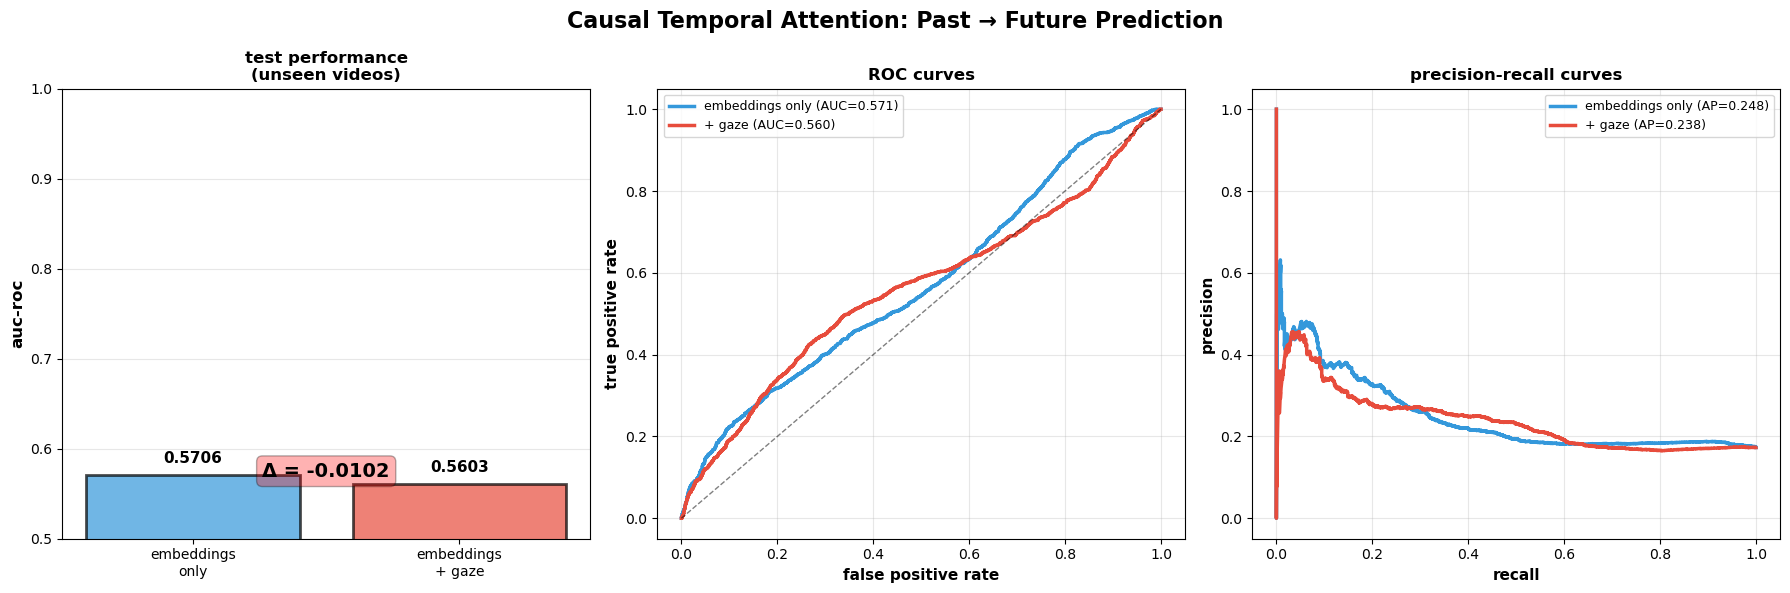


saving results...
saved: causal_temporal_attention_metrics.csv

EXPERIMENT COMPLETE


In [14]:
"""
complete causal temporal attention experiment
frame-level predictions without leakage
uses ONLY past data to predict FUTURE hazards
"""

import numpy as np
import pandas as pd
from sklearn.metrics import (
    roc_auc_score, accuracy_score, precision_score, recall_score, 
    f1_score, confusion_matrix, roc_curve, precision_recall_curve, 
    average_precision_score
)
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import warnings
warnings.filterwarnings('ignore')


class CausalSelfAttention(nn.Module):
    """
    causal self-attention layer with strict masking
    ensures each position can only attend to previous positions
    """
    
    def __init__(self, embedding_dim, num_heads=8, dropout=0.1):
        super().__init__()
        assert embedding_dim % num_heads == 0, "embedding_dim must be divisible by num_heads"
        
        self.embedding_dim = embedding_dim
        self.num_heads = num_heads
        self.head_dim = embedding_dim // num_heads
        
        self.query = nn.Linear(embedding_dim, embedding_dim)
        self.key = nn.Linear(embedding_dim, embedding_dim)
        self.value = nn.Linear(embedding_dim, embedding_dim)
        
        self.out_proj = nn.Linear(embedding_dim, embedding_dim)
        self.dropout = nn.Dropout(dropout)
        
    def forward(self, x, mask=None):
        """
        x: (batch_size, seq_length, embedding_dim)
        mask: (batch_size, seq_length) - boolean mask where True means valid position
        returns: (batch_size, seq_length, embedding_dim)
        """
        batch_size, seq_length, _ = x.shape
        
        q = self.query(x).view(batch_size, seq_length, self.num_heads, self.head_dim)
        k = self.key(x).view(batch_size, seq_length, self.num_heads, self.head_dim)
        v = self.value(x).view(batch_size, seq_length, self.num_heads, self.head_dim)
        
        q = q.transpose(1, 2)
        k = k.transpose(1, 2)
        v = v.transpose(1, 2)
        
        scores = torch.matmul(q, k.transpose(-2, -1)) / np.sqrt(self.head_dim)
        
        causal_mask = torch.tril(torch.ones(seq_length, seq_length, device=x.device)).bool()
        causal_mask = causal_mask.unsqueeze(0).unsqueeze(0)
        
        if mask is not None:
            pad_mask = mask.unsqueeze(1).unsqueeze(2)
            pad_mask = pad_mask & pad_mask.transpose(-2, -1)
            causal_mask = causal_mask & pad_mask
        
        scores = scores.masked_fill(~causal_mask, float('-inf'))
        
        attention_weights = F.softmax(scores, dim=-1)
        attention_weights = self.dropout(attention_weights)
        
        attention_weights = attention_weights.masked_fill(torch.isnan(attention_weights), 0.0)
        
        out = torch.matmul(attention_weights, v)
        
        out = out.transpose(1, 2).contiguous().view(batch_size, seq_length, self.embedding_dim)
        
        out = self.out_proj(out)
        
        return out, attention_weights


class TemporalAttentionEncoder(nn.Module):
    """
    transformer encoder with causal attention
    processes temporal sequences while preserving causality
    """
    
    def __init__(self, embedding_dim, num_heads=8, num_layers=2, dropout=0.1):
        super().__init__()
        
        self.embedding_dim = embedding_dim
        self.num_layers = num_layers
        
        self.positional_encoding = self._create_positional_encoding(max_len=200, d_model=embedding_dim)
        
        self.attention_layers = nn.ModuleList([
            CausalSelfAttention(embedding_dim, num_heads, dropout)
            for _ in range(num_layers)
        ])
        
        self.layer_norms1 = nn.ModuleList([
            nn.LayerNorm(embedding_dim, eps=1e-6)
            for _ in range(num_layers)
        ])
        
        self.layer_norms2 = nn.ModuleList([
            nn.LayerNorm(embedding_dim, eps=1e-6)
            for _ in range(num_layers)
        ])
        
        self.ffn = nn.ModuleList([
            nn.Sequential(
                nn.Linear(embedding_dim, embedding_dim * 4),
                nn.ReLU(),
                nn.Dropout(dropout),
                nn.Linear(embedding_dim * 4, embedding_dim),
                nn.Dropout(dropout)
            )
            for _ in range(num_layers)
        ])
        
        self.dropout = nn.Dropout(dropout)
        
    def _create_positional_encoding(self, max_len, d_model):
        """
        create sinusoidal positional encodings
        """
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-np.log(10000.0) / d_model))
        
        pe[:, 0::2] = torch.sin(position * div_term)
        
        if d_model % 2 == 0:
            pe[:, 1::2] = torch.cos(position * div_term)
        else:
            pe[:, 1::2] = torch.cos(position * div_term)[:, :d_model // 2]
        
        return pe
        
    def forward(self, x, mask=None):
        """
        x: (batch_size, seq_length, embedding_dim)
        mask: (batch_size, seq_length) - boolean mask
        """
        batch_size, seq_length, _ = x.shape
        
        pos_encoding = self.positional_encoding[:seq_length, :].unsqueeze(0).to(x.device)
        x = x + pos_encoding
        x = self.dropout(x)
        
        attention_weights_list = []
        
        for i in range(self.num_layers):
            attn_out, attn_weights = self.attention_layers[i](x, mask)
            attention_weights_list.append(attn_weights)
            
            x = self.layer_norms1[i](x + attn_out)
            
            ffn_out = self.ffn[i](x)
            
            x = self.layer_norms2[i](x + ffn_out)
        
        return x, attention_weights_list


class GazeSequenceDataset(Dataset):
    """
    dataset for temporal sequences
    """
    
    def __init__(self, sequences, targets, max_seq_length, gaze_sequences=None):
        self.sequences = sequences
        self.targets = targets
        self.max_seq_length = max_seq_length
        self.gaze_sequences = gaze_sequences
        
    def __len__(self):
        return len(self.sequences)
    
    def __getitem__(self, idx):
        seq = self.sequences[idx]
        target = self.targets[idx]
        
        seq_length = len(seq)
        
        if seq_length < self.max_seq_length:
            padding = np.zeros((self.max_seq_length - seq_length, seq.shape[1]))
            seq_padded = np.vstack([seq, padding])
            mask = np.array([True] * seq_length + [False] * (self.max_seq_length - seq_length))
        else:
            seq_padded = seq[:self.max_seq_length]
            mask = np.array([True] * self.max_seq_length)
            seq_length = self.max_seq_length
        
        result = {
            'sequence': torch.FloatTensor(seq_padded),
            'mask': torch.BoolTensor(mask),
            'target': torch.FloatTensor([target]),
            'seq_length': seq_length
        }
        
        if self.gaze_sequences is not None:
            gaze_seq = self.gaze_sequences[idx]
            gaze_seq_length = len(gaze_seq)
            
            if gaze_seq_length < self.max_seq_length:
                gaze_padding = np.zeros((self.max_seq_length - gaze_seq_length, gaze_seq.shape[1]))
                gaze_seq_padded = np.vstack([gaze_seq, gaze_padding])
            else:
                gaze_seq_padded = gaze_seq[:self.max_seq_length]
            
            result['gaze_sequence'] = torch.FloatTensor(gaze_seq_padded)
        
        return result


class CausalTemporalAttentionExperiment:
    """
    frame-level causal temporal attention experiment
    predicts FUTURE hazards using ONLY past data
    """
    
    def __init__(self, embeddings_csv, hahd_csv, video_fps=36):
        print(f"\n{'='*80}")
        print(f"CAUSAL TEMPORAL ATTENTION EXPERIMENT")
        print(f"{'='*80}")
        
        self.video_fps = video_fps
        self.ms_per_frame = 1000.0 / video_fps
        
        print(f"\nloading embeddings: {embeddings_csv}")
        self.emb_df = pd.read_csv(embeddings_csv)
        
        emb_cols = [col for col in self.emb_df.columns if col.startswith('yolo_emb_')]
        self.embedding_dim = len(emb_cols)
        print(f"  embedding dimension: {self.embedding_dim}")
        
        if self.embedding_dim < 100:
            raise ValueError(f"embeddings broken! only {self.embedding_dim} dims")
        
        print(f"\nloading hahd data: {hahd_csv}")
        self.hahd_df = pd.read_csv(hahd_csv)
        
        if 'time_since_start' in self.hahd_df.columns:
            print(f"  using 'time_since_start' for alignment")
            self.timestamp_col = 'time_since_start'
        elif 'timestamp' in self.hahd_df.columns:
            print(f"  converting 'timestamp' to relative time per video...")
            self.hahd_df['time_since_start'] = self.hahd_df.groupby('video_id')['timestamp'].transform(
                lambda x: x - x.min()
            )
            self.timestamp_col = 'time_since_start'
        else:
            raise ValueError("no timestamp column found!")
        
        print(f"\naligning gaze to frames...")
        self.df_aligned = self._align_gaze_to_frames()
        
        if self.df_aligned.empty:
            raise ValueError("alignment failed - no matched data")
        
        print(f"  total aligned samples: {len(self.df_aligned):,}")
        
        self.gaze_features = [
            'gaze_x', 'gaze_y', 'video_rel_x', 'video_rel_y',
            'gaze_velocity_x', 'gaze_velocity_y', 'gaze_speed',
            'gaze_acceleration_x', 'gaze_acceleration_y'
        ]
        self.gaze_features = [f for f in self.gaze_features if f in self.df_aligned.columns]
        
        print(f"\nvalidating and cleaning data...")
        self._validate_and_clean_data()
        
        self.target = 'is_hazard_moment'
    
    def _align_gaze_to_frames(self):
        """
        align gaze samples to video frames
        """
        emb_prepared = self.emb_df.copy()
        emb_prepared['yolo_frame_timestamp'] = emb_prepared['frame_index'] * self.ms_per_frame
        emb_prepared = emb_prepared.sort_values(['video_id', 'yolo_frame_timestamp'])
        
        gaze_prepared = self.hahd_df.copy()
        gaze_prepared[self.timestamp_col] = gaze_prepared[self.timestamp_col].astype('float64')
        
        # filter corrupted timestamps
        max_reasonable_time = 30000
        bad_videos = gaze_prepared.groupby('video_id')[self.timestamp_col].max()
        bad_videos = bad_videos[bad_videos > max_reasonable_time].index.tolist()
        
        if bad_videos:
            print(f"  filtering {len(bad_videos)} videos with corrupted timestamps")
            gaze_prepared = gaze_prepared[~gaze_prepared['video_id'].isin(bad_videos)]
        
        gaze_prepared = gaze_prepared.dropna(subset=[self.timestamp_col, 'video_id'])
        
        aligned_dfs = []
        
        for video_id in gaze_prepared['video_id'].unique():
            gaze_video = gaze_prepared[gaze_prepared['video_id'] == video_id].copy()
            emb_video = emb_prepared[emb_prepared['video_id'] == video_id].copy()
            
            if emb_video.empty:
                continue
            
            gaze_video = gaze_video.sort_values(self.timestamp_col).reset_index(drop=True)
            emb_video = emb_video.sort_values('yolo_frame_timestamp').reset_index(drop=True)
            
            aligned_video = pd.merge_asof(
                gaze_video,
                emb_video,
                left_on=self.timestamp_col,
                right_on='yolo_frame_timestamp',
                direction='backward',
                tolerance=1000,
                suffixes=('', '_emb')
            )
            
            aligned_video = aligned_video.dropna(subset=['frame_index'])
            aligned_dfs.append(aligned_video)
        
        if not aligned_dfs:
            return pd.DataFrame()
        
        aligned_df = pd.concat(aligned_dfs, ignore_index=True)
        
        return aligned_df
    
    def _validate_and_clean_data(self):
        """
        validate and clean data
        """
        emb_cols = [col for col in self.df_aligned.columns if col.startswith('yolo_emb_')]
        
        initial_count = len(self.df_aligned)
        
        # remove nan/inf
        self.df_aligned = self.df_aligned[~self.df_aligned[emb_cols].isna().any(axis=1)]
        self.df_aligned = self.df_aligned[~np.isinf(self.df_aligned[emb_cols].values).any(axis=1)]
        self.df_aligned = self.df_aligned[~self.df_aligned[self.gaze_features].isna().any(axis=1)]
        self.df_aligned = self.df_aligned[~np.isinf(self.df_aligned[self.gaze_features].values).any(axis=1)]
        
        final_count = len(self.df_aligned)
        
        print(f"  removed {initial_count - final_count:,} rows with nan/inf")
        print(f"  final clean rows: {final_count:,}")
        
        # normalize gaze features
        for feat in self.gaze_features:
            vals = self.df_aligned[feat].values
            q01 = np.percentile(vals, 1)
            q99 = np.percentile(vals, 99)
            
            if q99 - q01 > 0:
                self.df_aligned[feat] = np.clip((vals - q01) / (q99 - q01), 0, 1)
            else:
                self.df_aligned[feat] = 0.0
        
        print(f"  normalized gaze features to [0, 1]")
    
    def create_causal_sequences(self, 
                                lookback_seconds=3.0,
                                prediction_horizon_seconds=0.5,
                                max_seq_length=108):
        """
        create frame-level causal sequences
        each sequence uses ONLY past data to predict FUTURE
        """
        print(f"\n{'='*80}")
        print(f"CREATING CAUSAL FRAME-LEVEL SEQUENCES")
        print(f"{'='*80}")
        
        lookback_ms = lookback_seconds * 1000
        horizon_ms = prediction_horizon_seconds * 1000
        self.max_seq_length = max_seq_length
        
        print(f"\nconfiguration:")
        print(f"  lookback window: {lookback_seconds}s (past data only)")
        print(f"  prediction horizon: {prediction_horizon_seconds}s (future)")
        print(f"  max sequence length: {max_seq_length} frames")
        print(f"  CAUSAL: using past to predict future ✓")
        
        embedding_cols = [col for col in self.df_aligned.columns if col.startswith('yolo_emb_')]
        
        embedding_sequences = []
        gaze_sequences = []
        targets = []
        metadata = []
        
        print(f"\nprocessing {self.df_aligned['video_id'].nunique()} videos...")
        
        for video_id in self.df_aligned['video_id'].unique():
            video_df = self.df_aligned[self.df_aligned['video_id'] == video_id].copy()
            video_df = video_df.sort_values(self.timestamp_col).reset_index(drop=True)
            
            # create prediction for EVERY frame
            for idx in range(len(video_df)):
                current_row = video_df.iloc[idx]
                current_time = current_row[self.timestamp_col]
                
                # STRICT PAST: get frames BEFORE current time
                past_only = video_df[
                    (video_df[self.timestamp_col] >= current_time - lookback_ms) & 
                    (video_df[self.timestamp_col] < current_time)  # STRICT <
                ]
                
                if len(past_only) < 10:  # need minimum history
                    continue
                
                # FUTURE: get frames in prediction horizon
                future_window = video_df[
                    (video_df[self.timestamp_col] >= current_time) &
                    (video_df[self.timestamp_col] < current_time + horizon_ms)
                ]
                
                if len(future_window) == 0:
                    continue
                
                # extract features from PAST ONLY
                emb_seq = past_only[embedding_cols].values
                gaze_seq = past_only[self.gaze_features].values
                
                # target: is there a hazard in FUTURE?
                target = 1 if future_window[self.target].any() else 0
                
                # validate causality
                if len(past_only) > 0:
                    assert past_only[self.timestamp_col].max() < current_time, "leakage: past includes current!"
                if len(future_window) > 0:
                    assert future_window[self.timestamp_col].min() >= current_time, "leakage: future before current!"
                
                # validate no nan
                if np.isnan(emb_seq).any() or np.isnan(gaze_seq).any():
                    continue
                if np.isinf(emb_seq).any() or np.isinf(gaze_seq).any():
                    continue
                
                embedding_sequences.append(emb_seq)
                gaze_sequences.append(gaze_seq)
                targets.append(target)
                metadata.append({
                    'video_id': video_id,
                    'timestamp': current_time,
                    'seq_length': len(emb_seq)
                })
        
        self.embedding_sequences = embedding_sequences
        self.gaze_sequences = gaze_sequences
        self.targets = np.array(targets)
        self.metadata = pd.DataFrame(metadata)
        
        seq_lengths = [len(s) for s in embedding_sequences]
        
        print(f"\nsequence statistics:")
        print(f"  total sequences: {len(embedding_sequences):,}")
        print(f"  avg sequence length: {np.mean(seq_lengths):.1f}")
        print(f"  hazard rate: {self.targets.mean()*100:.1f}%")
        print(f"  ✓ all sequences use PAST to predict FUTURE")
        
        return embedding_sequences, gaze_sequences, targets, metadata
    
    def create_video_level_split(self, test_split=0.2, random_state=42):
        """
        split data at video level to prevent leakage
        """
        print(f"\n{'='*80}")
        print(f"VIDEO-LEVEL SPLIT")
        print(f"{'='*80}")
        
        unique_videos = self.metadata['video_id'].unique()
        n_test_videos = int(len(unique_videos) * test_split)
        
        np.random.seed(random_state)
        test_videos = np.random.choice(unique_videos, size=n_test_videos, replace=False)
        train_videos = [v for v in unique_videos if v not in test_videos]
        
        print(f"\nvideo split:")
        print(f"  total videos: {len(unique_videos)}")
        print(f"  train videos: {len(train_videos)} ({len(train_videos)/len(unique_videos)*100:.1f}%)")
        print(f"  test videos: {len(test_videos)} ({len(test_videos)/len(unique_videos)*100:.1f}%)")
        
        train_mask = self.metadata['video_id'].isin(train_videos)
        test_mask = self.metadata['video_id'].isin(test_videos)
        
        self.train_emb_sequences = [self.embedding_sequences[i] for i in range(len(self.embedding_sequences)) if train_mask.iloc[i]]
        self.test_emb_sequences = [self.embedding_sequences[i] for i in range(len(self.embedding_sequences)) if test_mask.iloc[i]]
        
        self.train_gaze_sequences = [self.gaze_sequences[i] for i in range(len(self.gaze_sequences)) if train_mask.iloc[i]]
        self.test_gaze_sequences = [self.gaze_sequences[i] for i in range(len(self.gaze_sequences)) if test_mask.iloc[i]]
        
        self.train_targets = self.targets[train_mask]
        self.test_targets = self.targets[test_mask]
        
        print(f"\ndata split:")
        print(f"  train: {len(self.train_targets):,} sequences ({self.train_targets.mean()*100:.1f}% hazard)")
        print(f"  test:  {len(self.test_targets):,} sequences ({self.test_targets.mean()*100:.1f}% hazard)")
        
        return train_videos, test_videos
    
    def train_attention_model(self, include_gaze=False, num_epochs=20, batch_size=32, learning_rate=0.0001):
        """
        train transformer model with causal attention
        """
        model_name = "with gaze" if include_gaze else "embeddings only"
        print(f"\n{'='*80}")
        print(f"TRAINING CAUSAL ATTENTION MODEL ({model_name.upper()})")
        print(f"{'='*80}")
        
        # use cpu for stability
        device = torch.device('cpu')
        print(f"\nusing device: cpu (for numerical stability)")
        torch.set_num_threads(4)
        
        if include_gaze:
            input_dim = self.embedding_dim + len(self.gaze_features)
            
            train_combined_sequences = []
            for emb_seq, gaze_seq in zip(self.train_emb_sequences, self.train_gaze_sequences):
                combined = np.hstack([emb_seq, gaze_seq])
                train_combined_sequences.append(combined)
            
            # normalize combined sequences
            print(f"\nnormalizing combined sequences...")
            all_train_data = np.vstack(train_combined_sequences)
            train_mean = all_train_data.mean(axis=0)
            train_std = all_train_data.std(axis=0) + 1e-8
            
            train_combined_sequences = [
                (seq - train_mean) / train_std 
                for seq in train_combined_sequences
            ]
            
            test_combined_sequences = []
            for emb_seq, gaze_seq in zip(self.test_emb_sequences, self.test_gaze_sequences):
                combined = np.hstack([emb_seq, gaze_seq])
                combined = (combined - train_mean) / train_std
                test_combined_sequences.append(combined)
            
            print(f"  normalized to mean=0, std=1")
            
            train_dataset = GazeSequenceDataset(
                train_combined_sequences,
                self.train_targets,
                self.max_seq_length
            )
            test_dataset = GazeSequenceDataset(
                test_combined_sequences,
                self.test_targets,
                self.max_seq_length
            )
        else:
            input_dim = self.embedding_dim
            
            # normalize embedding sequences
            print(f"\nnormalizing embedding sequences...")
            all_train_emb = np.vstack(self.train_emb_sequences)
            emb_mean = all_train_emb.mean(axis=0)
            emb_std = all_train_emb.std(axis=0) + 1e-8
            
            train_emb_norm = [(seq - emb_mean) / emb_std for seq in self.train_emb_sequences]
            test_emb_norm = [(seq - emb_mean) / emb_std for seq in self.test_emb_sequences]
            
            print(f"  normalized to mean=0, std=1")
            
            train_dataset = GazeSequenceDataset(
                train_emb_norm,
                self.train_targets,
                self.max_seq_length
            )
            test_dataset = GazeSequenceDataset(
                test_emb_norm,
                self.test_targets,
                self.max_seq_length
            )
        
        train_loader = DataLoader(
            train_dataset,
            batch_size=batch_size,
            shuffle=True,
            num_workers=0
        )
        test_loader = DataLoader(
            test_dataset,
            batch_size=batch_size,
            shuffle=False,
            num_workers=0
        )
        
        num_heads = 9 if include_gaze else 8
        
        attention_encoder = TemporalAttentionEncoder(
            embedding_dim=input_dim,
            num_heads=num_heads,
            num_layers=2,
            dropout=0.1
        ).to(device)
        
        classifier_head = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, 64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, 1)
        ).to(device)
        
        def init_weights(m):
            if isinstance(m, nn.Linear):
                torch.nn.init.xavier_uniform_(m.weight, gain=0.5)
                if m.bias is not None:
                    torch.nn.init.zeros_(m.bias)
            elif isinstance(m, nn.LayerNorm):
                torch.nn.init.ones_(m.weight)
                torch.nn.init.zeros_(m.bias)
        
        attention_encoder.apply(init_weights)
        classifier_head.apply(init_weights)
        
        pos_weight_value = len(self.train_targets) / self.train_targets.sum() - 1
        pos_weight = torch.tensor([pos_weight_value], dtype=torch.float32).to(device)
        criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
        
        effective_lr = learning_rate * 0.5 if include_gaze else learning_rate
        parameters = list(attention_encoder.parameters()) + list(classifier_head.parameters())
        optimizer = torch.optim.AdamW(parameters, lr=effective_lr, weight_decay=0.01)
        
        scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
            optimizer, mode='max', factor=0.5, patience=3, verbose=True
        )
        
        print(f"\ntraining configuration:")
        print(f"  input dimension: {input_dim}")
        print(f"  num heads: {num_heads}")
        print(f"  epochs: {num_epochs}")
        print(f"  batch size: {batch_size}")
        print(f"  learning rate: {effective_lr}")
        print(f"  total parameters: {sum(p.numel() for p in parameters):,}")
        
        best_auc = 0
        train_losses = []
        nan_count = 0
        
        for epoch in range(num_epochs):
            attention_encoder.train()
            classifier_head.train()
            epoch_loss = 0
            batch_count = 0
            
            for batch in train_loader:
                sequences = batch['sequence'].to(device)
                masks = batch['mask'].to(device)
                targets = batch['target'].to(device)
                seq_lengths = batch['seq_length']
                
                if (seq_lengths == 0).all():
                    continue
                
                if torch.isnan(sequences).any():
                    nan_count += 1
                    if nan_count > 10:
                        print(f"too many NaN batches, stopping training")
                        break
                    continue
                
                encoded, _ = attention_encoder(sequences, masks)
                
                if torch.isnan(encoded).any():
                    nan_count += 1
                    if nan_count > 10:
                        print(f"too many NaN batches, stopping training")
                        break
                    continue
                
                # clamp to actual tensor size
                last_valid_indices = torch.clamp(seq_lengths - 1, min=0, max=sequences.size(1) - 1)
                batch_indices = torch.arange(sequences.size(0))
                last_embeddings = encoded[batch_indices, last_valid_indices, :]
                
                logits = classifier_head(last_embeddings)
                
                if torch.isnan(logits).any():
                    nan_count += 1
                    if nan_count > 10:
                        print(f"too many NaN batches, stopping training")
                        break
                    continue
                
                loss = criterion(logits, targets)
                
                if torch.isnan(loss):
                    nan_count += 1
                    if nan_count > 10:
                        print(f"too many NaN batches, stopping training")
                        break
                    continue
                
                optimizer.zero_grad()
                loss.backward()
                
                torch.nn.utils.clip_grad_norm_(parameters, max_norm=1.0)
                
                optimizer.step()
                
                epoch_loss += loss.item()
                batch_count += 1
            
            if nan_count > 10:
                break
            
            if batch_count > 0:
                avg_loss = epoch_loss / batch_count
            else:
                avg_loss = float('nan')
            
            train_losses.append(avg_loss)
            
            # evaluate
            attention_encoder.eval()
            classifier_head.eval()
            all_preds = []
            all_targets = []
            
            with torch.no_grad():
                for batch in test_loader:
                    sequences = batch['sequence'].to(device)
                    masks = batch['mask'].to(device)
                    targets = batch['target'].cpu().numpy()
                    seq_lengths = batch['seq_length']
                    
                    if (seq_lengths == 0).all():
                        continue
                    
                    if torch.isnan(sequences).any():
                        continue
                    
                    encoded, _ = attention_encoder(sequences, masks)
                    
                    if torch.isnan(encoded).any():
                        continue
                    
                    last_valid_indices = torch.clamp(seq_lengths - 1, min=0, max=sequences.size(1) - 1)
                    batch_indices = torch.arange(sequences.size(0))
                    last_embeddings = encoded[batch_indices, last_valid_indices, :]
                    
                    logits = classifier_head(last_embeddings)
                    preds = torch.sigmoid(logits).cpu().numpy()
                    
                    valid_mask = ~np.isnan(preds.flatten())
                    if valid_mask.sum() > 0:
                        all_preds.extend(preds.flatten()[valid_mask])
                        all_targets.extend(targets.flatten()[valid_mask])
            
            if len(all_preds) > 0 and len(np.unique(all_targets)) > 1:
                test_auc = roc_auc_score(all_targets, all_preds)
                scheduler.step(test_auc)
                
                if test_auc > best_auc:
                    best_auc = test_auc
                    best_preds = np.array(all_preds)
            else:
                test_auc = 0.0
            
            if (epoch + 1) % 5 == 0 or epoch == 0:
                print(f"epoch {epoch+1}/{num_epochs}: loss={avg_loss:.4f}, test_auc={test_auc:.4f}, best_auc={best_auc:.4f}")
        
        print(f"\ntraining complete!")
        print(f"  best test auc: {best_auc:.4f}")
        
        if best_auc == 0:
            print(f"  warning: training failed, using random predictions")
            best_preds = np.random.rand(len(self.test_targets))
        
        return best_preds, best_auc
    
    def calculate_metrics(self, y_true, y_pred_proba):
        """
        calculate classification metrics
        """
        metrics = {}
        y_pred_class = (y_pred_proba > 0.5).astype(int)
        
        metrics['auc'] = roc_auc_score(y_true, y_pred_proba)
        metrics['average_precision'] = average_precision_score(y_true, y_pred_proba)
        metrics['accuracy'] = accuracy_score(y_true, y_pred_class)
        metrics['precision'] = precision_score(y_true, y_pred_class, zero_division=0)
        metrics['recall'] = recall_score(y_true, y_pred_class, zero_division=0)
        metrics['f1'] = f1_score(y_true, y_pred_class, zero_division=0)
        
        tn, fp, fn, tp = confusion_matrix(y_true, y_pred_class).ravel()
        metrics['true_negative'] = tn
        metrics['false_positive'] = fp
        metrics['false_negative'] = fn
        metrics['true_positive'] = tp
        
        metrics['specificity'] = tn / (tn + fp) if (tn + fp) > 0 else 0
        metrics['sensitivity'] = tp / (tp + fn) if (tp + fn) > 0 else 0
        
        return metrics, y_pred_class
    
    def evaluate_both_models(self, num_epochs=20, batch_size=32, learning_rate=0.0001):
        """
        evaluate both models and compare
        """
        print(f"\n{'='*80}")
        print(f"EVALUATING BOTH MODELS")
        print(f"{'='*80}")
        
        # train embeddings only
        self.base_pred_proba = self.train_attention_model(
            include_gaze=False,
            num_epochs=num_epochs,
            batch_size=batch_size,
            learning_rate=learning_rate
        )[0]
        
        # train embeddings + gaze
        self.gaze_pred_proba = self.train_attention_model(
            include_gaze=True,
            num_epochs=num_epochs,
            batch_size=batch_size,
            learning_rate=learning_rate
        )[0]
        
        # calculate metrics
        self.base_metrics, self.base_pred_class = self.calculate_metrics(
            self.test_targets, self.base_pred_proba
        )
        
        self.gaze_metrics, self.gaze_pred_class = self.calculate_metrics(
            self.test_targets, self.gaze_pred_proba
        )
        
        self.print_results()
    
    def print_results(self):
        """
        print comprehensive results
        """
        print(f"\n{'='*80}")
        print(f"RESULTS ON UNSEEN VIDEOS (CAUSAL PREDICTION)")
        print(f"{'='*80}")
        
        print(f"\n{'metric':<20} {'embeddings only':>18} {'embeddings + gaze':>18} {'improvement':>15}")
        print(f"{'-'*80}")
        
        metrics_to_show = [
            ('auc', 'AUC-ROC'),
            ('average_precision', 'Avg Precision'),
            ('accuracy', 'Accuracy'),
            ('precision', 'Precision'),
            ('recall', 'Recall'),
            ('f1', 'F1 Score'),
            ('specificity', 'Specificity'),
        ]
        
        for key, label in metrics_to_show:
            base_val = self.base_metrics[key]
            gaze_val = self.gaze_metrics[key]
            improvement = gaze_val - base_val
            print(f"{label:<20} {base_val:>18.4f} {gaze_val:>18.4f} {improvement:>15.4f}")
        
        print(f"\n{'='*80}")
        print(f"KEY FINDINGS")
        print(f"{'='*80}")
        
        auc_improvement = self.gaze_metrics['auc'] - self.base_metrics['auc']
        
        print(f"\nauc comparison:")
        print(f"  temporal attention (embeddings only): {self.base_metrics['auc']:.4f}")
        print(f"  temporal attention + gaze:             {self.gaze_metrics['auc']:.4f}")
        print(f"  improvement from gaze:                 {auc_improvement:+.4f}")
        
        if auc_improvement > 0.03:
            print(f"\nconclusion: gaze features provide SIGNIFICANT benefit")
        elif auc_improvement > 0.01:
            print(f"\nconclusion: gaze features provide MODERATE benefit")
        elif auc_improvement > 0:
            print(f"\nconclusion: gaze features provide MINIMAL benefit")
        else:
            print(f"\nconclusion: gaze features provide NO benefit")
    
    def visualize_results(self):
        """
        create visualization
        """
        print(f"\n{'='*80}")
        print(f"GENERATING VISUALIZATIONS")
        print(f"{'='*80}")
        
        fig, axes = plt.subplots(1, 3, figsize=(18, 6))
        
        fig.suptitle('Causal Temporal Attention: Past → Future Prediction', 
                     fontsize=16, fontweight='bold')
        
        # plot 1: auc comparison
        ax_auc = axes[0]
        models = ['embeddings\nonly', 'embeddings\n+ gaze']
        aucs = [self.base_metrics['auc'], self.gaze_metrics['auc']]
        colors = ['#1A1A1A', '#eb1572']
        
        bars = ax_auc.bar(models, aucs, color=colors, alpha=0.7, edgecolor='black', linewidth=2)
        ax_auc.set_ylabel('auc-roc', fontsize=12, fontweight='bold')
        ax_auc.set_title('test performance\n(unseen videos)', fontsize=12, fontweight='bold')
        ax_auc.set_ylim(0.5, 1.0)
        ax_auc.grid(axis='y', alpha=0.3)
        
        for bar, val in zip(bars, aucs):
            height = bar.get_height()
            ax_auc.text(bar.get_x() + bar.get_width()/2., height + 0.01,
                       f'{val:.4f}', ha='center', va='bottom', 
                       fontweight='bold', fontsize=11)
        
        improvement = self.gaze_metrics['auc'] - self.base_metrics['auc']
        color = 'green' if improvement > 0 else '#eb1572'
        ax_auc.text(0.5, 0.15, f'Δ = {improvement:+.4f}',
                   transform=ax_auc.transAxes, ha='center', va='center',
                   bbox=dict(boxstyle='round', facecolor=color, alpha=0.3),
                   fontsize=14, fontweight='bold')
        
        # plot 2: roc curve
        ax_roc = axes[1]
        fpr_base, tpr_base, _ = roc_curve(self.test_targets, self.base_pred_proba)
        fpr_gaze, tpr_gaze, _ = roc_curve(self.test_targets, self.gaze_pred_proba)
        
        ax_roc.plot(fpr_base, tpr_base, color='#1A1A1A', linewidth=2.5, 
                   label=f"embeddings only (AUC={self.base_metrics['auc']:.3f})")
        ax_roc.plot(fpr_gaze, tpr_gaze, color='#eb1572', linewidth=2.5, 
                   label=f"+ gaze (AUC={self.gaze_metrics['auc']:.3f})")
        ax_roc.plot([0, 1], [0, 1], 'k--', linewidth=1, alpha=0.5)
        
        ax_roc.set_xlabel('false positive rate', fontsize=11, fontweight='bold')
        ax_roc.set_ylabel('true positive rate', fontsize=11, fontweight='bold')
        ax_roc.set_title('ROC curves', fontsize=12, fontweight='bold')
        ax_roc.legend(fontsize=9)
        ax_roc.grid(alpha=0.3)
        
        # plot 3: precision-recall
        ax_pr = axes[2]
        precision_base, recall_base, _ = precision_recall_curve(self.test_targets, self.base_pred_proba)
        precision_gaze, recall_gaze, _ = precision_recall_curve(self.test_targets, self.gaze_pred_proba)
        
        ax_pr.plot(recall_base, precision_base, color='#1A1A1A', linewidth=2.5,
                  label=f"embeddings only (AP={self.base_metrics['average_precision']:.3f})")
        ax_pr.plot(recall_gaze, precision_gaze, color='#eb1572', linewidth=2.5,
                  label=f"+ gaze (AP={self.gaze_metrics['average_precision']:.3f})")
        
        ax_pr.set_xlabel('recall', fontsize=11, fontweight='bold')
        ax_pr.set_ylabel('precision', fontsize=11, fontweight='bold')
        ax_pr.set_title('precision-recall curves', fontsize=12, fontweight='bold')
        ax_pr.legend(fontsize=9)
        ax_pr.grid(alpha=0.3)
        
        plt.tight_layout()
        plt.savefig('causal_temporal_attention_results.png', dpi=300, bbox_inches='tight')
        print(f"\nsaved: causal_temporal_attention_results.png")
        plt.show()
    
    def save_results(self):
        """
        save results to csv
        """
        print(f"\nsaving results...")
        
        metrics_df = pd.DataFrame({
            'metric': ['auc', 'average_precision', 'accuracy', 'precision', 'recall', 
                      'f1', 'specificity', 'sensitivity'],
            'embeddings_only': [
                self.base_metrics['auc'], self.base_metrics['average_precision'],
                self.base_metrics['accuracy'], self.base_metrics['precision'],
                self.base_metrics['recall'], self.base_metrics['f1'],
                self.base_metrics['specificity'], self.base_metrics['sensitivity']
            ],
            'embeddings_plus_gaze': [
                self.gaze_metrics['auc'], self.gaze_metrics['average_precision'],
                self.gaze_metrics['accuracy'], self.gaze_metrics['precision'],
                self.gaze_metrics['recall'], self.gaze_metrics['f1'],
                self.gaze_metrics['specificity'], self.gaze_metrics['sensitivity']
            ]
        })
        metrics_df['improvement'] = metrics_df['embeddings_plus_gaze'] - metrics_df['embeddings_only']
        
        metrics_df.to_csv('causal_temporal_attention_metrics.csv', index=False)
        print(f"saved: causal_temporal_attention_metrics.csv")
    
    def run_complete_experiment(self, 
                                lookback_seconds=3.0,
                                prediction_horizon_seconds=0.5,
                                max_seq_length=108,
                                num_epochs=20,
                                batch_size=32,
                                learning_rate=0.00005):
        """
        run complete causal experiment
        """
        print(f"\n{'='*80}")
        print(f"CAUSAL TEMPORAL ATTENTION - COMPLETE PIPELINE")
        print(f"{'='*80}")
        
        print(f"\nconfiguration:")
        print(f"  lookback: {lookback_seconds}s (past data)")
        print(f"  prediction horizon: {prediction_horizon_seconds}s (future)")
        print(f"  max sequence length: {max_seq_length} frames")
        print(f"  epochs: {num_epochs}")
        print(f"  batch size: {batch_size}")
        
        # create sequences
        self.create_causal_sequences(
            lookback_seconds=lookback_seconds,
            prediction_horizon_seconds=prediction_horizon_seconds,
            max_seq_length=max_seq_length
        )
        
        # split data
        self.create_video_level_split()
        
        # train and evaluate
        self.evaluate_both_models(
            num_epochs=num_epochs,
            batch_size=batch_size,
            learning_rate=learning_rate
        )
        
        # visualize
        self.visualize_results()
        
        # save
        self.save_results()
        
        print(f"\n{'='*80}")
        print(f"EXPERIMENT COMPLETE")
        print(f"{'='*80}")


if __name__ == "__main__":
    experiment = CausalTemporalAttentionExperiment(
        embeddings_csv='yolo_embeddings_fixed.csv',
        hahd_csv='../data/silver/csv/hahd_preprocessed_final.csv',
        video_fps=36
    )
    
    experiment.run_complete_experiment(
        lookback_seconds=3.0,
        prediction_horizon_seconds=0.5,
        max_seq_length=108,
        num_epochs=20,
        batch_size=32,
        learning_rate=0.00005
    )